**I. EDA — Thị Trường IT Việt Nam**

**Mục tiêu:** Kể một câu chuyện liền mạch về thị trường IT Việt Nam

---

**II. Data Lineage**

```
df_raw                   ← CSV gốc: df_clean_llm_enriched_kaggle.csv
  └── df                 ← + date_posted_clean parsed, + month column
        ├── df_city      ← df lọc theo city_group (chỉ TPHCM & Hà Nội, đã tiền xử lý)
        └── df_expertise_group  ← df + merge job_expertise_new_groups.xlsx
              └── df_domain_group  ← + merge df_domains.csv + job_domain_group.xlsx
```


---


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ast
from matplotlib.colors import to_hex
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlepad': 14,
    'axes.labelpad': 7,
    'axes.titlesize': 13,
})

CITY_COLORS = {
    'TPHCM': '#1abc9c',
    'Hà Nội': '#e74c3c',
}

WM_COLORS = {
    'At office': '#e74c3c',
    'Hybrid':    '#f39c12',
    'Remote':    '#2ecc71',
}

def get_color_map(df, column, base_palette='tab20'):
    """Tạo color map nhất quán, ưu tiên màu VIP cho city."""
    unique_values = sorted(df[column].dropna().unique())
    palette = sns.color_palette(base_palette, len(unique_values))
    color_map = {}
    for i, value in enumerate(unique_values):
        if value in CITY_COLORS:
            color_map[value] = CITY_COLORS[value]
        else:
            color_map[value] = palette[i]
    return color_map

def parse_list_col(x):
    """Parse cột dạng string list '["a", "b"]' thành list Python."""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

print('Config xong.')

Config xong.


In [20]:

df_raw = pd.read_csv('df_clean_llm_enriched_kaggle.csv')

df = df_raw.copy()
df['date_posted_clean'] = pd.to_datetime(df['date_posted_clean'])
df['month'] = df['date_posted_clean'].dt.to_period('M').dt.to_timestamp()

df_city = df.copy()
df_city['city_group'] = df_city['city_group'].str.split(' & ')
df_city = df_city.explode('city_group')
df_city['city_group'] = df_city['city_group'].str.strip()
df_ai = df[df['ai_related'] == True].copy()

# Coverage report
print(f'Tổng unique job postings : {len(df):,}')
print(f'Thành phố trong dataset  : {df_city["city_group"].value_counts().to_dict()}')
print(f'Khoảng thời gian         : {df["month"].min().strftime("%Y-%m")} → {df["month"].max().strftime("%Y-%m")}')
print(f'Số tháng                 : {df["month"].nunique()}')
print(f'Số công ty               : {df["company_name"].nunique():,}')
print(f'Missing rate during_days : {df["during_days"].isna().mean()*100:.1f}%')

Tổng unique job postings : 1,735
Thành phố trong dataset  : {'TPHCM': 1138, 'Hà Nội': 712}
Khoảng thời gian         : 2026-01 → 2026-04
Số tháng                 : 4
Số công ty               : 656
Missing rate during_days : 0.0%


In [21]:
grouped_expertise = pd.read_excel('job_expertise_new_groups.xlsx')
df_expertise_group = df.merge(grouped_expertise, on='job_expertise', how='left')

job_domain    = pd.read_csv('df_domains.csv')
domain_groups = pd.read_excel('job_domain_group.xlsx')

df_domain = df_expertise_group.merge(job_domain, on='elem_id', how='inner')
df_domain_group = df_domain.merge(domain_groups, on='domain_name', how='left')

#Check lần 2
pct_covered = len(df_domain) / len(df) * 100
print(f'df_expertise_group : {len(df_expertise_group):,} rows (= df, left join)')
print(f'df_domain          : {len(df_domain):,} rows ({pct_covered:.1f}% of df) — inner join với domain')
print(f'df_domain_group    : {len(df_domain_group):,} rows')


df_expertise_group : 1,735 rows (= df, left join)
df_domain          : 3,202 rows (184.6% of df) — inner join với domain
df_domain_group    : 3,202 rows


# **I. BỨC TRANH TỔNG THỂ**

Tỷ lệ job theo thành phố

/tmp/ipykernel_2906/1629868719.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




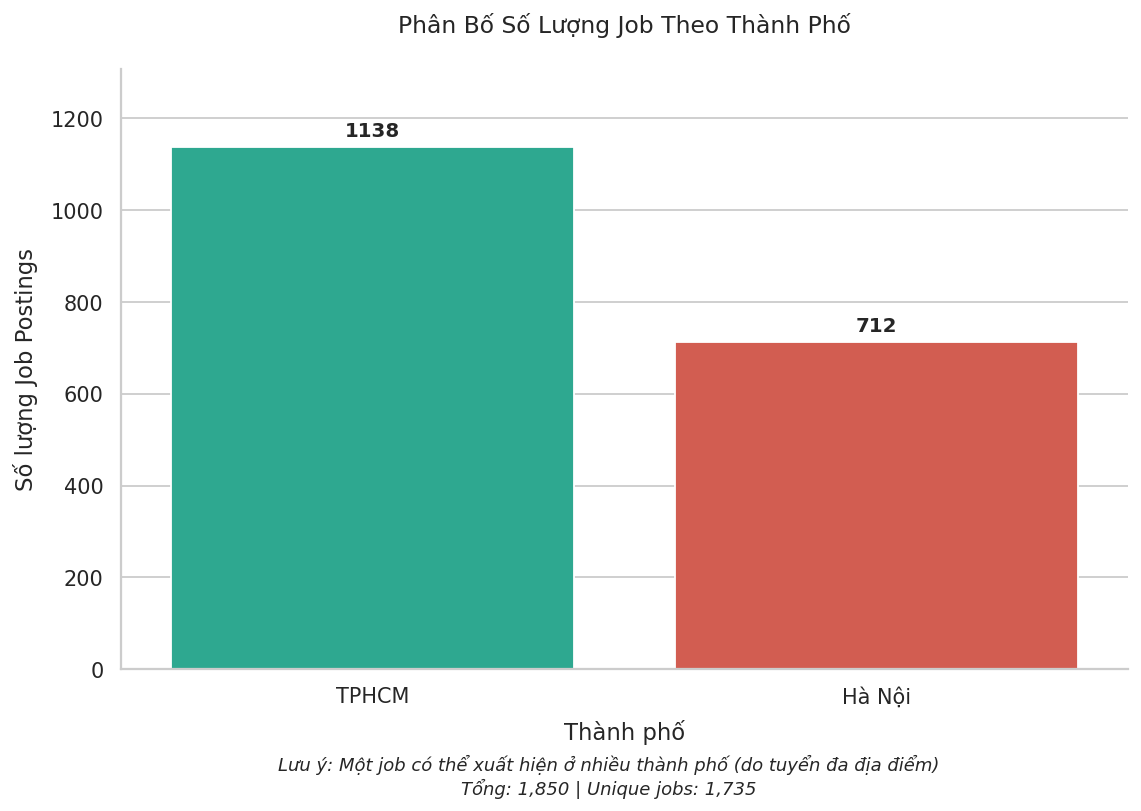

In [6]:
total_jobs = len(df_city)
unique_jobs = df["elem_id"].nunique()

city_colors = get_color_map(df_city, "city_group")

city_counts = df_city['city_group'].value_counts().reset_index()
city_counts.columns = ['City', 'Job Count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=city_counts,
    x='City',
    y='Job Count',
    palette=city_colors
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title("Phân Bố Số Lượng Job Theo Thành Phố", pad=20)
plt.ylabel("Số lượng Job Postings")
plt.xlabel("Thành phố")
plt.ylim(0, city_counts['Job Count'].max() * 1.15)

note = (
    "Lưu ý: Một job có thể xuất hiện ở nhiều thành phố (do tuyển đa địa điểm)\n"
    f"Tổng: {total_jobs:,} | Unique jobs: {unique_jobs:,}"
)

plt.figtext(
    0.5, -0.05, note,
    ha="center",
    fontsize=10,
    style='italic'
)

sns.despine()
plt.show()

Company Type × Size Distribution

* Câu hỏi : Ai đang tạo ra thị trường việc làm IT?
* Cho ai  : Tất cả — bức tranh vĩ mô đầu tiên
* Insight  : Loại công ty nào chiếm ưu thế, size nào phổ biến


In [5]:
company_colors    = get_color_map(df, 'company_type')
company_colors_px = {k: (v if isinstance(v, str) else to_hex(v)) for k, v in company_colors.items()}

_tmp = df[['company_type', 'company_size', 'during_days']].dropna(subset=['company_type', 'company_size'])

grouped_tree = (
    _tmp.groupby(['company_type', 'company_size'])
    .agg(count=('company_type', 'size'), median_days=('during_days', 'median'))
    .reset_index()
)

fig = px.treemap(
    grouped_tree,
    path=['company_type', 'company_size'],
    values='count',
    color='company_type',
    color_discrete_map=company_colors_px,
    title=f'Company Type & Size Distribution — {len(df):,} job postings',
    hover_data={'median_days': ':.0f'},
)
fig.update_traces(textinfo='label+percent parent', textfont_size=13)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Jobs by Expertise Group (macro view)
* Câu hỏi : Thị trường đang ưu tiên nhóm nhân sự nào?
* Cho ai  : Job seeker — định hướng ngành nghề
* Insight  : Nhóm nào chiếm áp đảo, nhóm nào đang niche

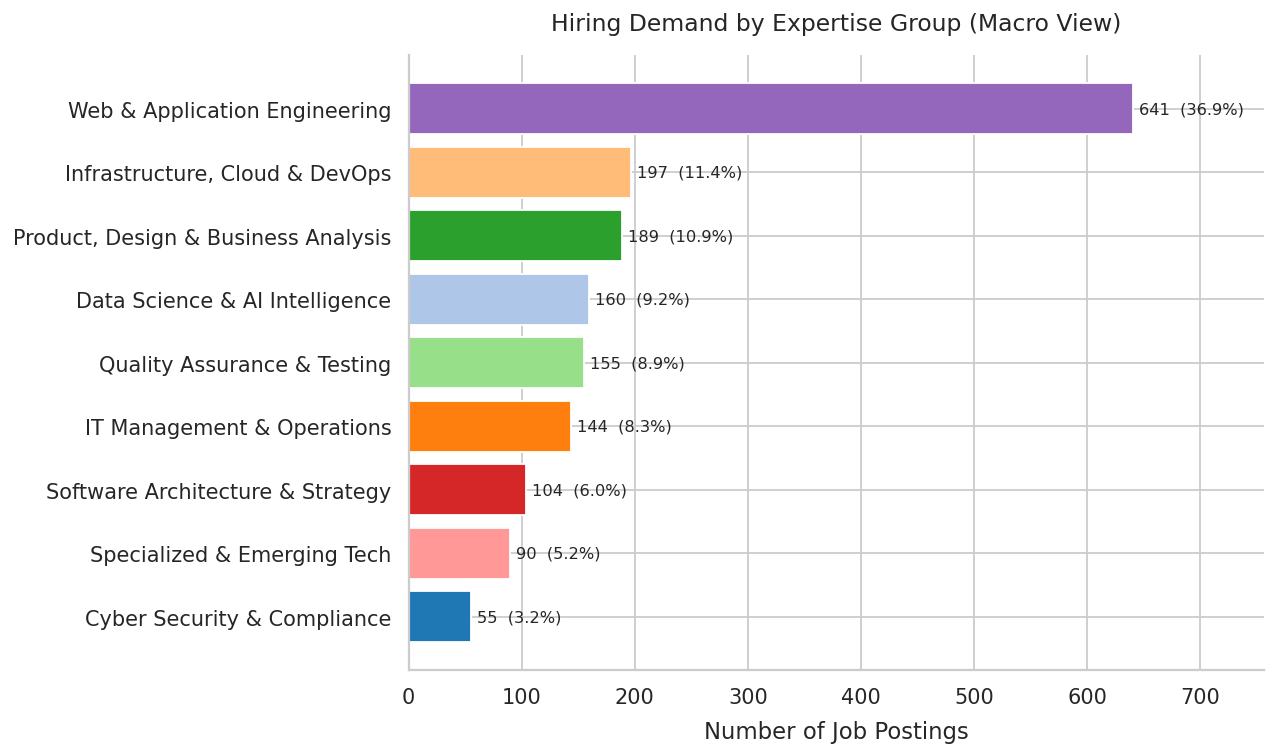

In [8]:
expertise_colors = get_color_map(df_expertise_group, 'expertise_group')
table_exp = df_expertise_group['expertise_group'].value_counts().sort_values(ascending=True)
total_jobs = table_exp.sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    table_exp.index, table_exp.values,
    color=[expertise_colors.get(x, '#bdc3c7') for x in table_exp.index]
)

for i, v in enumerate(table_exp.values):
    pct = v / total_jobs * 100
    ax.text(v + total_jobs * 0.003, i, f'{v:,}  ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Number of Job Postings')
ax.set_title('Hiring Demand by Expertise Group (Macro View)')

ax.set_xlim(0, table_exp.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

Expertise Group Share Over Time — Highlight Chart
* Câu hỏi : Nhóm expertise nào đang tăng/giảm thị phần?
* Cho ai  : Job seeker & HR — biết xu hướng dài hạn
* Insight : Highlight top 5 nhóm lớn nhất, fade phần còn lại

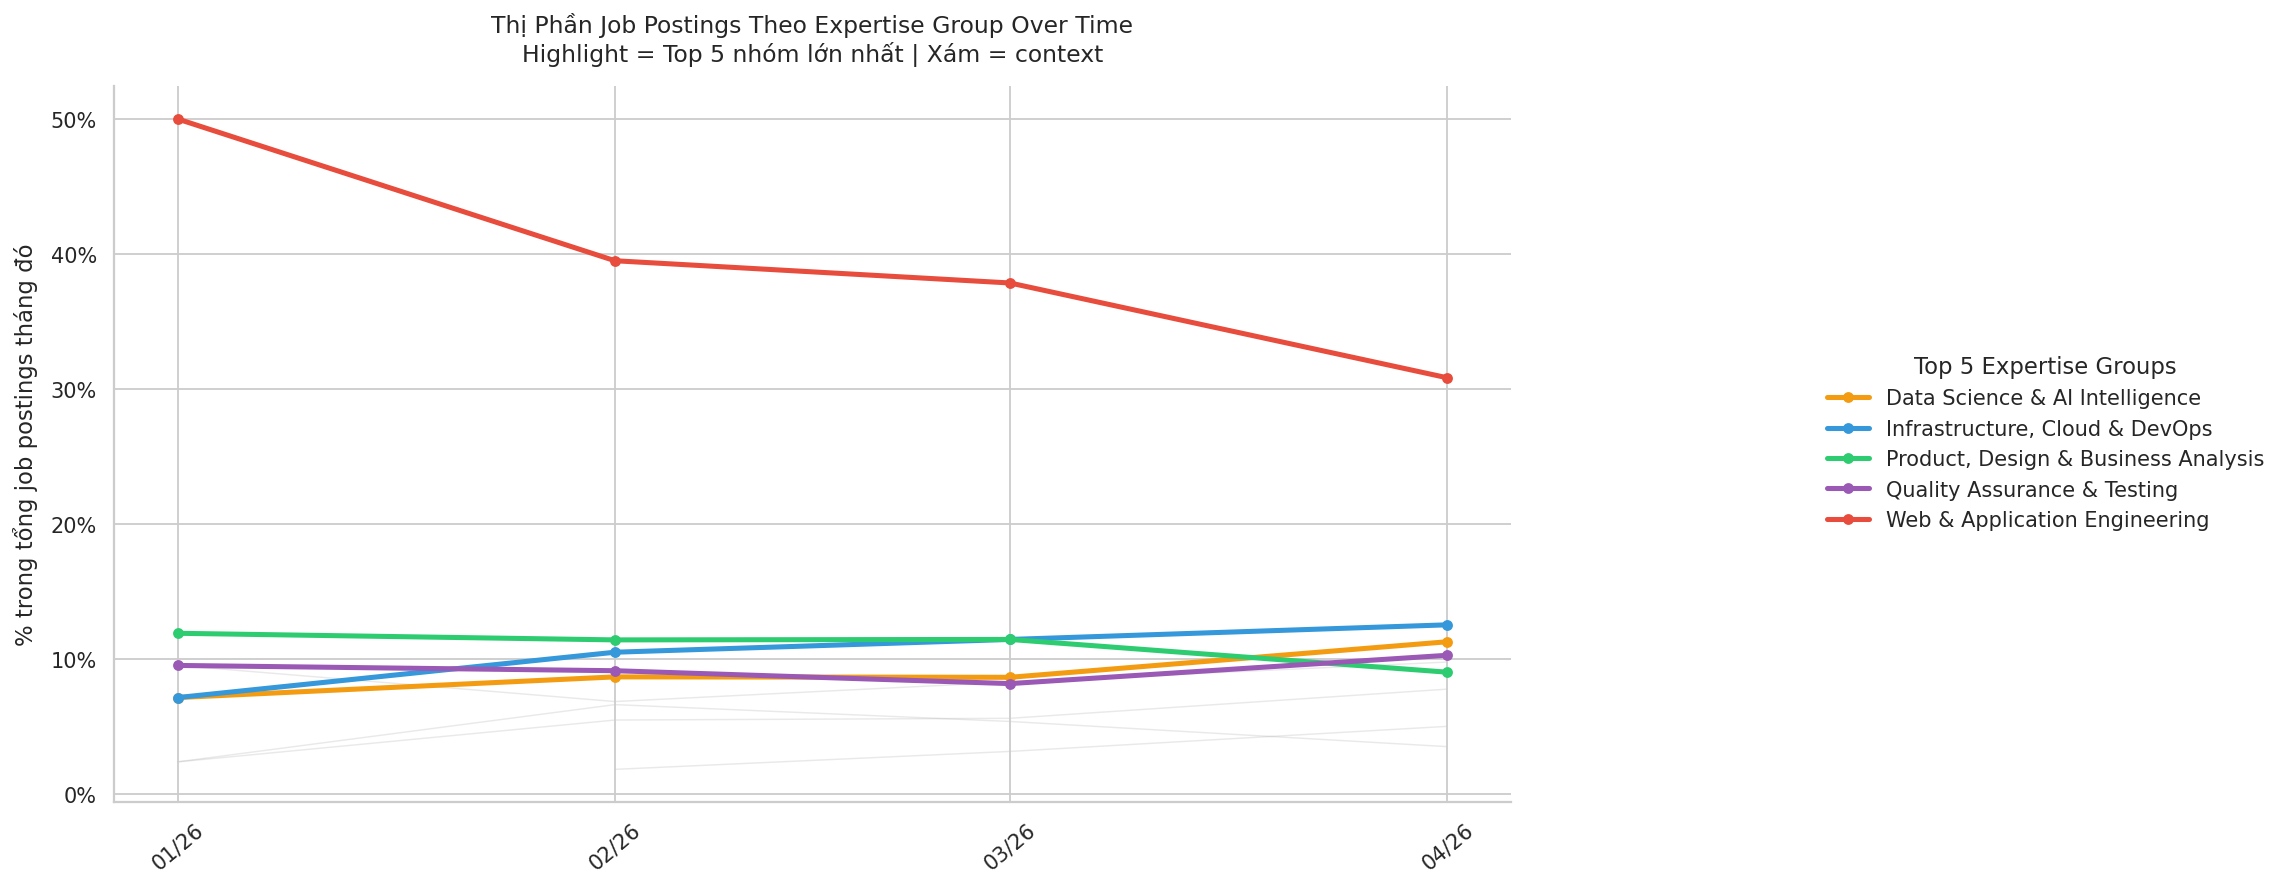

In [13]:
_tmp_exp_trend = df_expertise_group.copy()

table_exp_time = (
    _tmp_exp_trend
    .groupby(['month', 'expertise_group'])
    .size()
    .reset_index(name='count')
)

table_exp_time['total'] = table_exp_time.groupby('month')['count'].transform('sum')
table_exp_time['percent'] = table_exp_time['count'] / table_exp_time['total'] * 100
table_exp_time = table_exp_time.sort_values('month')

# Top 5 theo tổng số job postings toàn kỳ
top5_exp = (
    table_exp_time
    .groupby('expertise_group')['count']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

highlight_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
top5_colors = {g: c for g, c in zip(top5_exp, highlight_palette)}

handles = []
labels = []

fig, ax = plt.subplots(figsize=(14, 7))

for group, gdf in table_exp_time.groupby('expertise_group'):
    gdf = gdf.sort_values('month')

    if group in top5_exp:
        c = top5_colors[group]
        line, = ax.plot(
            gdf['month'],
            gdf['percent'],
            color=c,
            linewidth=2.8,
            marker='o',
            markersize=5,
            zorder=5
        )
        handles.append(line)
        labels.append(group)
    else:
        ax.plot(
            gdf['month'],
            gdf['percent'],
            color='#a9a9a9',
            linewidth=0.8,
            alpha=0.25,
            zorder=0
        )

ax.set_xticks(sorted(table_exp_time['month'].unique()))
ax.set_ylabel('% trong tổng job postings tháng đó')
ax.set_title(
    'Thị Phần Job Postings Theo Expertise Group Over Time\n'
    'Highlight = Top 5 nhóm lớn nhất | Xám = context'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    title='Top 5 Expertise Groups'
)

plt.xticks(rotation=40)
sns.despine()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# **II. NHU CẦU TUYỂN DỤNG CỐT LÕI**

Top 15 Job Expetise
* Câu hỏi : Toàn ngành thì top 15 vai trò nào đang được tuyển nhiều nhất?
* Cho ai  : Job seeker — biết cụ thể Thị trường đang nghiêng về đâu và có xu hướng gì
* Insight  : "Đặt lên bàn cân cả những công việc không thuộc chung 1 nhóm ngành

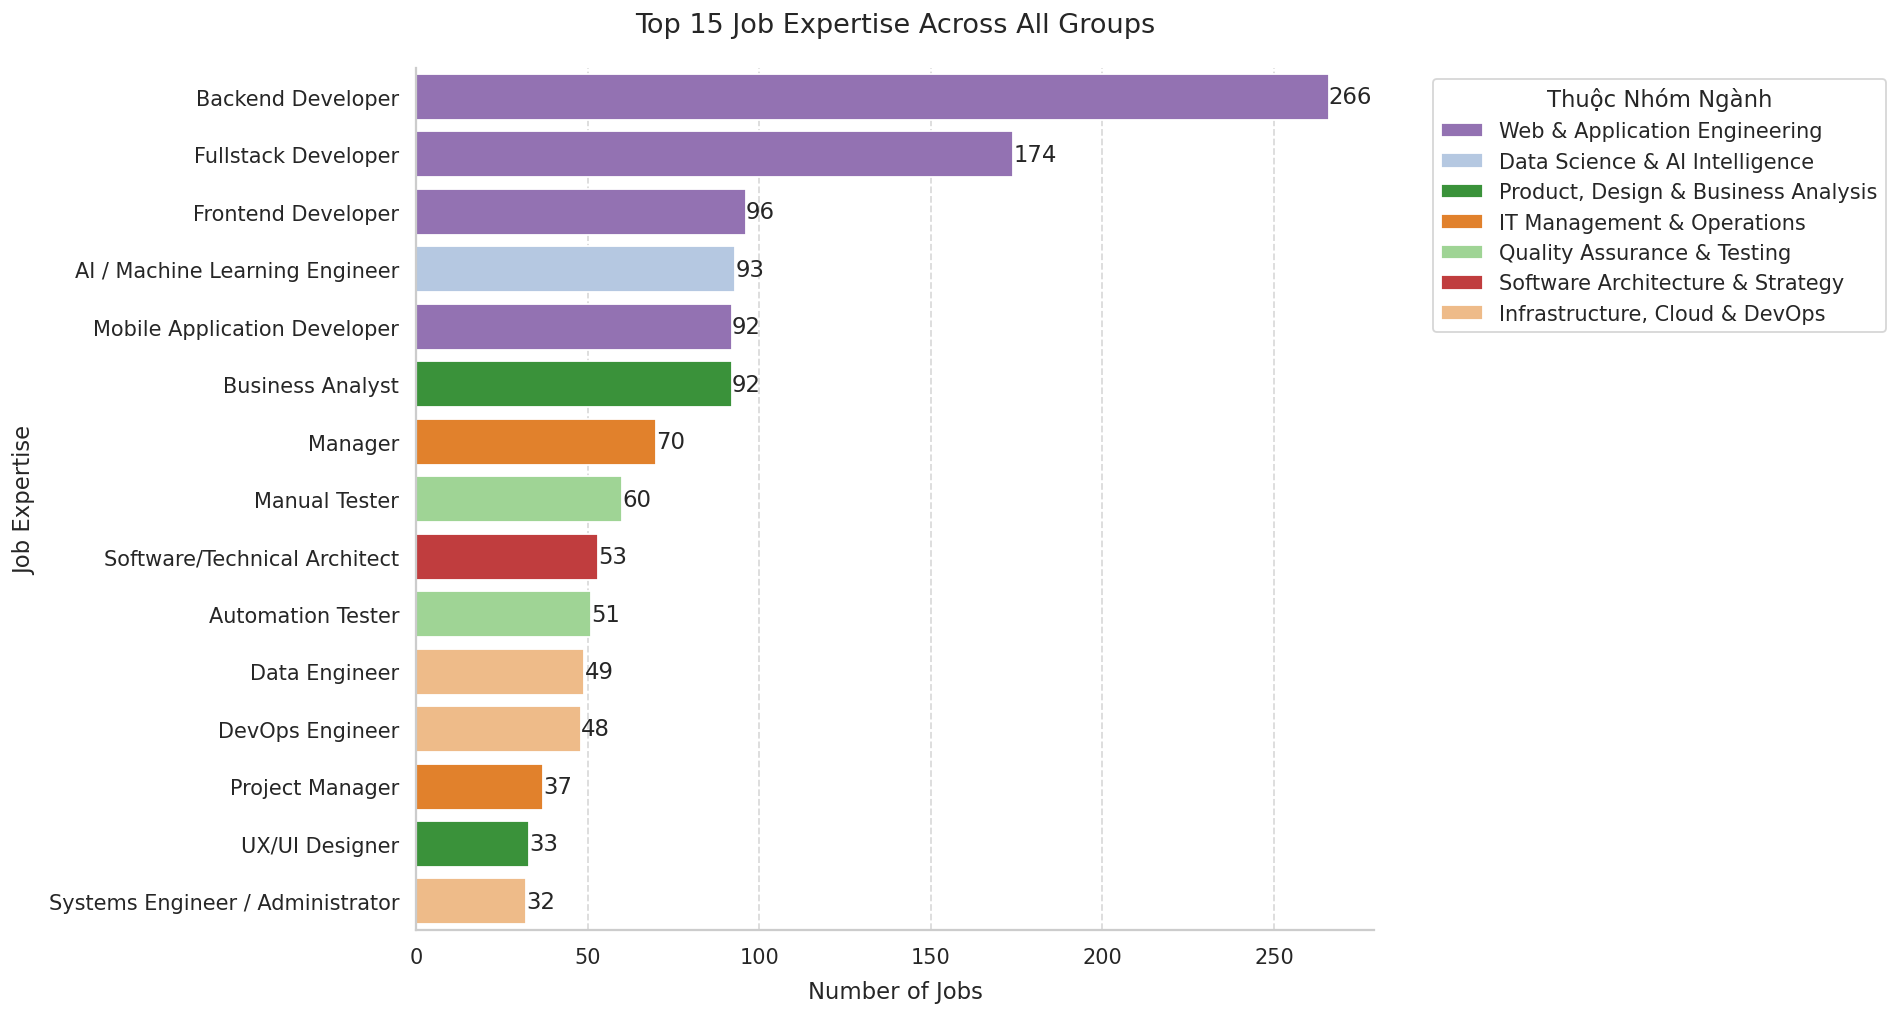

In [24]:
expertise_group_colors = get_color_map(df_expertise_group, "expertise_group")

top_15_all = df_expertise_group['job_expertise'].value_counts().head(15).reset_index()
top_15_all.columns = ['job_expertise', 'count']

mapping = df_expertise_group[['job_expertise', 'expertise_group']].drop_duplicates(subset=['job_expertise'])
top_15_final = top_15_all.merge(mapping, on='job_expertise', how='left')

plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=top_15_final,
    x='count',
    y='job_expertise',
    hue='expertise_group',
    dodge=False,
    palette=expertise_group_colors
)

plt.title("Top 15 Job Expertise Across All Groups", fontsize=15, pad=20)
plt.xlabel("Number of Jobs")
plt.ylabel("Job Expertise")

for i, v in enumerate(top_15_final['count']):
    plt.text(v, i, str(v), va='center')

plt.legend(title="Thuộc Nhóm Ngành", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

Top 10 Programming Languages
* Câu hỏi : Ngôn ngữ lập trình nào thị trường đòi hỏi nhiều nhất?
* Cho ai  : Developer — biết nên ưu tiên học/thành thạo ngôn ngữ nào
* Insight  : Python/Java/JS vẫn top? Hay có ngôn ngữ nào đang nổi lên?

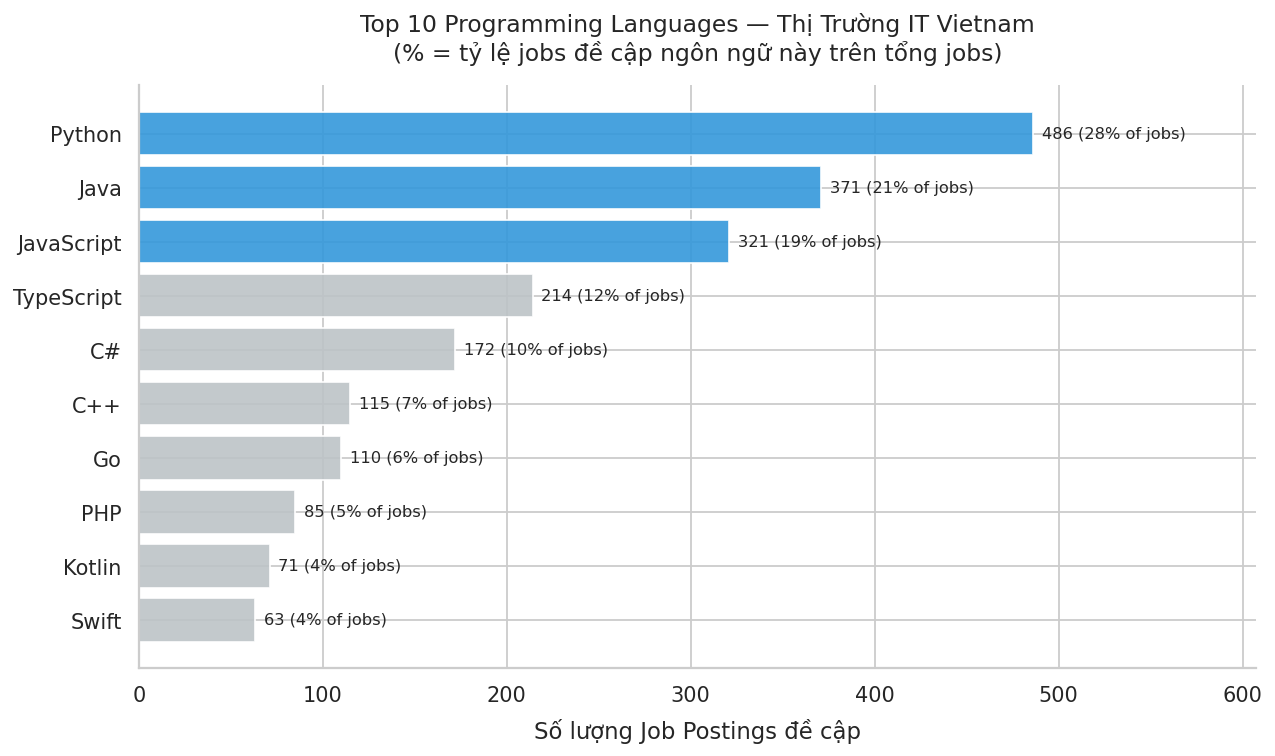

In [25]:
_tmp_lang = df[['programming_languages_flat']].dropna().copy()
_tmp_lang['programming_languages_flat'] = _tmp_lang['programming_languages_flat'].apply(parse_list_col)
_tmp_lang = _tmp_lang.explode('programming_languages_flat')
_tmp_lang['programming_languages_flat'] = _tmp_lang['programming_languages_flat'].str.strip()
_tmp_lang = _tmp_lang[_tmp_lang['programming_languages_flat'].ne('')]

top_10_langs = _tmp_lang['programming_languages_flat'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#3498db' if i < 3 else '#bdc3c7' for i in range(len(top_10_langs))]
ax.barh(top_10_langs.index[::-1], top_10_langs.values[::-1], color=bar_colors[::-1], alpha=0.9)

for i, v in enumerate(top_10_langs.values[::-1]):
    pct = v / len(df) * 100
    ax.text(v + top_10_langs.max() * 0.01, i, f'{v:,} ({pct:.0f}% of jobs)',
            va='center', fontsize=9)

ax.set_xlabel('Số lượng Job Postings đề cập')
ax.set_title('Top 10 Programming Languages — Thị Trường IT Vietnam\n'
             '(% = tỷ lệ jobs đề cập ngôn ngữ này trên tổng jobs)')
ax.set_xlim(0, top_10_langs.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

Top 12 Programming Language X Framework
* Câu hỏi : Những cặp ngôn ngữ lập trình x framework có độ tương quan cao nhấT?
* Cho ai  : Developer — biết khi học Language này nên đi cùng framework nào? Biết sự phân bố của thị trường
* Insight  : Học C# đi cùng .NET

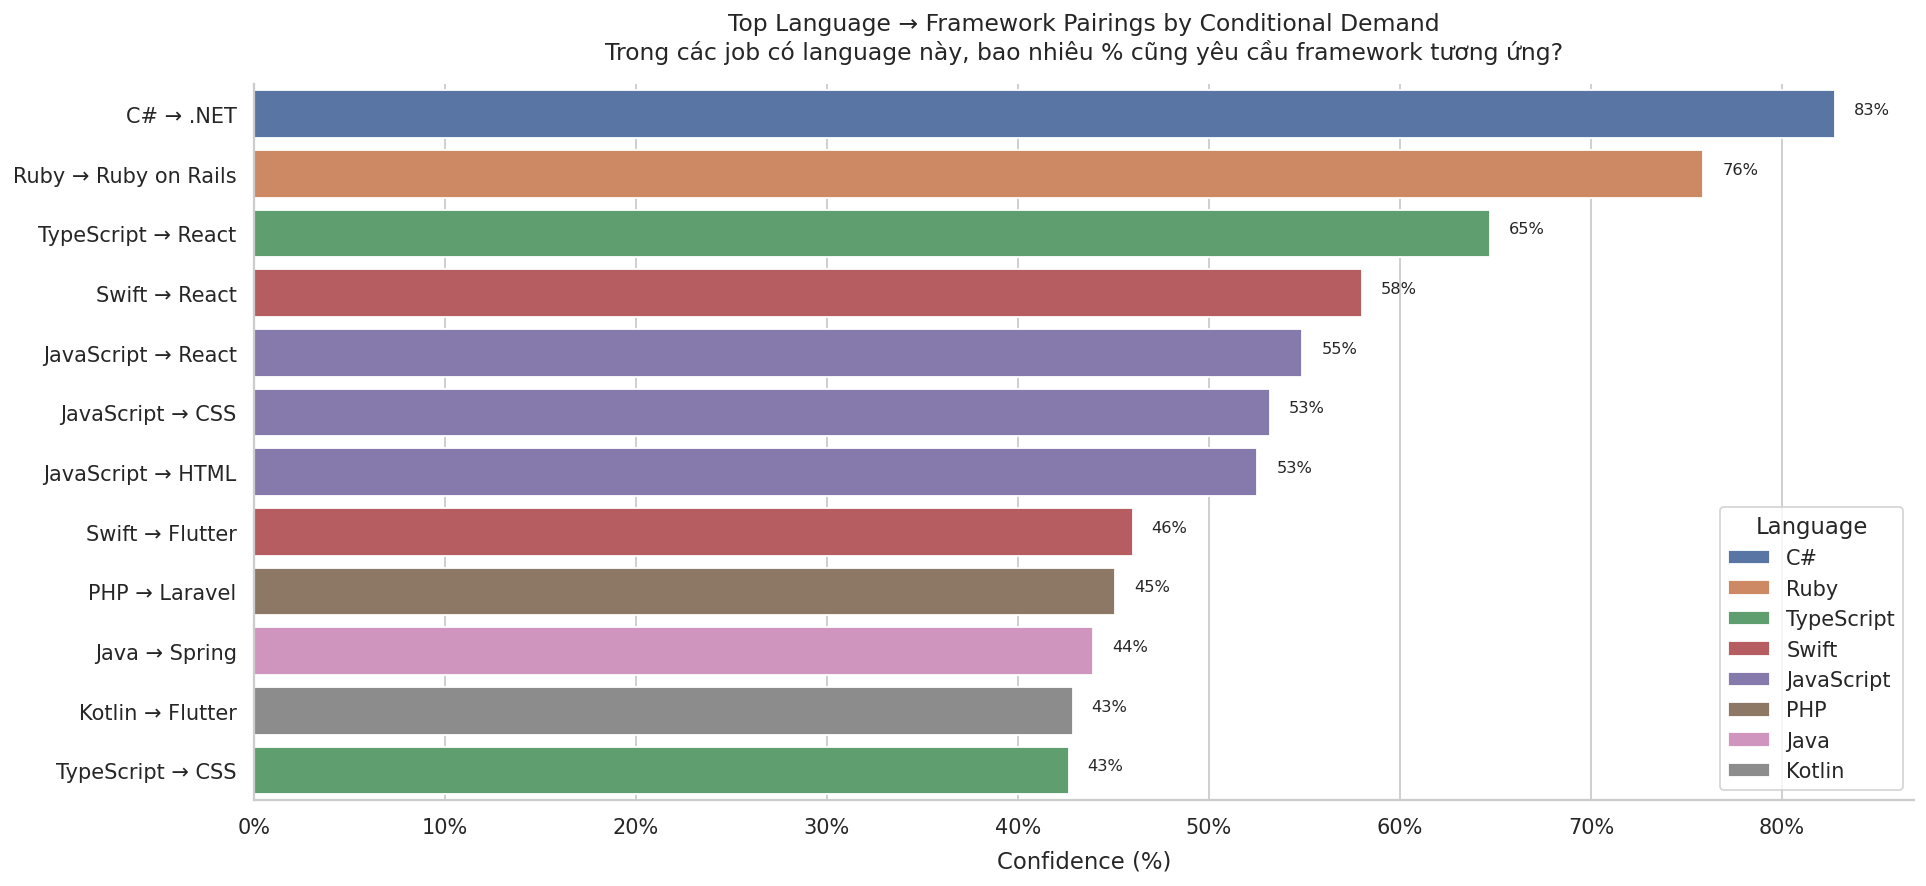

In [26]:
_tmp = df[['programming_languages_flat', 'frameworks_libraries_flat']].dropna().copy()

_tmp['programming_languages_flat'] = _tmp['programming_languages_flat'].apply(parse_list_col)
_tmp['frameworks_libraries_flat'] = _tmp['frameworks_libraries_flat'].apply(parse_list_col)

_tmp['programming_languages_flat'] = _tmp['programming_languages_flat'].apply(
    lambda lst: sorted(set([x.strip() for x in lst if isinstance(x, str) and x.strip() != '']))
)
_tmp['frameworks_libraries_flat'] = _tmp['frameworks_libraries_flat'].apply(
    lambda lst: sorted(set([x.strip() for x in lst if isinstance(x, str) and x.strip() != '']))
)

_tmp = _tmp[
    (_tmp['programming_languages_flat'].map(len) > 0) &
    (_tmp['frameworks_libraries_flat'].map(len) > 0)
].copy()

n_jobs = len(_tmp)

all_langs = _tmp['programming_languages_flat'].explode().value_counts()
all_fws = _tmp['frameworks_libraries_flat'].explode().value_counts()

lang_counts_all = all_langs.to_dict()
fw_counts_all = all_fws.to_dict()

pair_counts = {}

for _, row in _tmp.iterrows():
    langs = row['programming_languages_flat']
    fws = row['frameworks_libraries_flat']

    for lang in langs:
        for fw in fws:
            key = (lang, fw)
            pair_counts[key] = pair_counts.get(key, 0) + 1

pairs_df = pd.DataFrame(
    [
        {
            'Language': lang,
            'Framework': fw,
            'Support': support,
            'Language_jobs': lang_counts_all[lang],
            'Framework_jobs': fw_counts_all[fw],
            'Confidence_%': support / lang_counts_all[lang] * 100,
            'Framework_Base_%': fw_counts_all[fw] / n_jobs * 100,
            'Lift': (support / lang_counts_all[lang]) / (fw_counts_all[fw] / n_jobs)
        }
        for (lang, fw), support in pair_counts.items()
    ]
)

min_support = 15
min_confidence = 20
min_lang_jobs = 20

strong_pairs = pairs_df[
    (pairs_df['Support'] >= min_support) &
    (pairs_df['Confidence_%'] >= min_confidence) &
    (pairs_df['Language_jobs'] >= min_lang_jobs)
].copy()

strong_pairs = strong_pairs.sort_values(
    by=['Confidence_%', 'Support', 'Lift'],
    ascending=[False, False, False]
)

plot_top_n = 12

plot_df = (
    strong_pairs.copy()
    .sort_values(by=['Confidence_%', 'Support', 'Lift'], ascending=[False, False, False])
    .head(plot_top_n)
    .copy()
)

plot_df['Pair'] = plot_df['Language'] + ' → ' + plot_df['Framework']

plt.figure(figsize=(15, 7))
ax = sns.barplot(
    data=plot_df,
    y='Pair',
    x='Confidence_%',
    hue='Language',
    dodge=False
)

ax.set_title(
    'Top Language → Framework Pairings by Conditional Demand\n'
    'Trong các job có language này, bao nhiêu % cũng yêu cầu framework tương ứng?'
)
ax.set_xlabel('Confidence (%)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Language', loc='best')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row['Confidence_%'] + 1,
        i,
        f"{row['Confidence_%']:.0f}%",
        fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.show()

Những ngôn ngữ còn lại trong top 10 sẽ đi cùng với framework?
* Câu hỏi: Java đi với Spring Boot bao nhiêu %, với Spring bao nhiêu?
* Cho ai: Thị trường - Developer
* Insight: Thị trường đang phân mảnh, một ngôn ngữ cần biết cách dung hòa framework

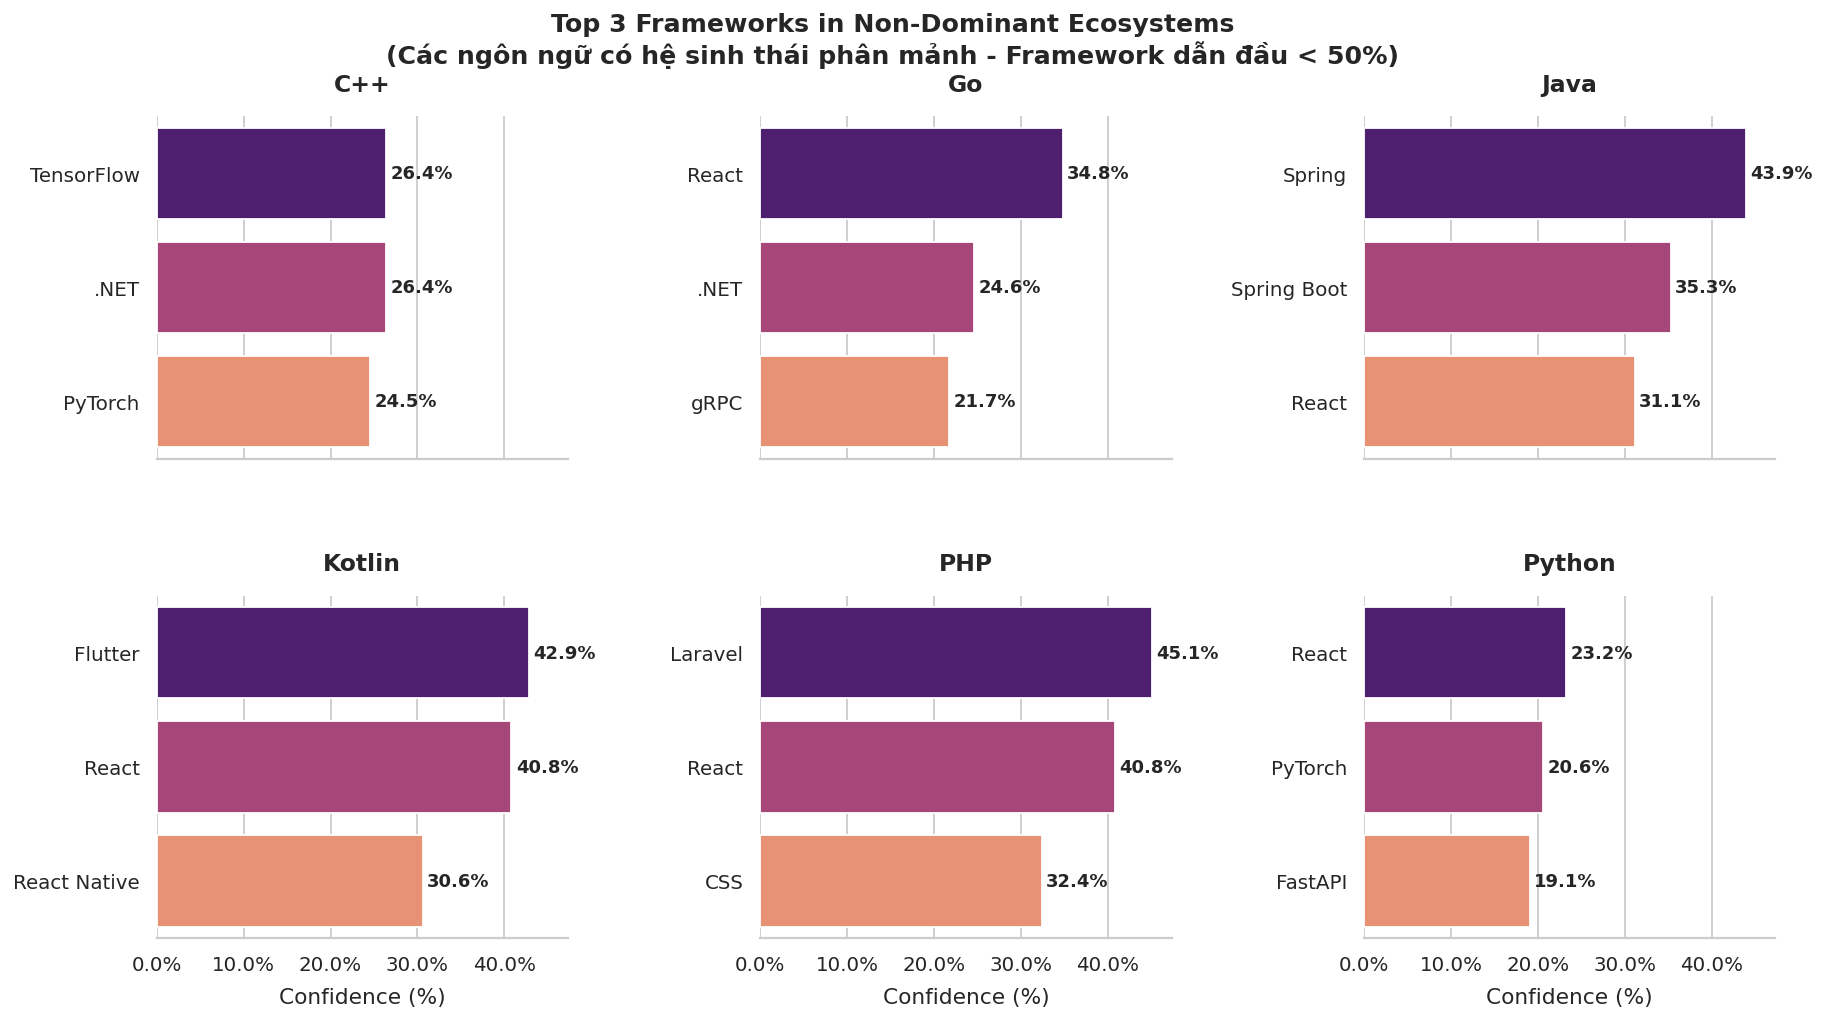

In [27]:
import matplotlib.ticker as mtick

# Lấy framework dẫn đầu của mỗi ngôn ngữ
top_fw_per_lang = (
    pairs_df
    .sort_values(by=['Language', 'Confidence_%'], ascending=[True, False])
    .groupby('Language')
    .head(1)
)

# Lọc trong Top 10 và lấy các ngôn ngữ "yếu" (< 50%)
target_langs = top_10_langs.index.tolist()
weak_langs = top_fw_per_lang[
    (top_fw_per_lang['Language'].isin(target_langs)) &
    (top_fw_per_lang['Confidence_%'] < 50)
]['Language'].tolist()

# Lấy Top 3 Framework cho từng ngôn ngữ này
plot_df = (
    pairs_df[pairs_df['Language'].isin(weak_langs)]
    .copy()
    .sort_values(by=['Language', 'Confidence_%'], ascending=[True, False])
    .groupby('Language')
    .head(3)
)

sns.set_theme(style="whitegrid")

# Sử dụng FacetGrid trực tiếp để kiểm soát thứ tự trục Y của từng ngôn ngữ
g = sns.FacetGrid(
    plot_df,
    col="Language",
    col_wrap=3,
    sharey=False,
    sharex=True,
    height=4,
    aspect=1.2
)

# Định nghĩa hàm vẽ barplot riêng cho từng facet để tránh lỗi gán nhãn
def draw_bar(data, **kwargs):
    # Sắp xếp nội bộ để Framework cao nhất nằm trên cùng
    data = data.sort_values('Confidence_%', ascending=False)
    ax = sns.barplot(data=data, x='Confidence_%', y='Framework', hue='Framework', palette='magma', legend=False)

    # Annotate ngay trong lúc vẽ để đảm bảo tọa độ chính xác
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(
                f"{width:.1f}%",
                (width + 0.5, p.get_y() + p.get_height()/2),
                va='center',
                fontsize=10,
                fontweight='bold'
            )

# Map hàm vẽ vào Grid
g.map_dataframe(draw_bar)

g.set_titles("{col_name}", weight='bold', size=13)
g.set_axis_labels("Confidence (%)", "")

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    sns.despine(ax=ax, left=True)

plt.subplots_adjust(top=0.88, hspace=0.4)
g.fig.suptitle(
    'Top 3 Frameworks in Non-Dominant Ecosystems\n'
    '(Các ngôn ngữ có hệ sinh thái phân mảnh - Framework dẫn đầu < 50%)',
    fontsize=14,
    weight='bold'
)

plt.show()

Câu hỏi: Theo cấp bậc, cơ cấu kĩ năng có sự khác biệt gì?
* Cho ai: Developer
* Insight: Càng lên cao, cấp bậc càng ưu tiên về hệ thống

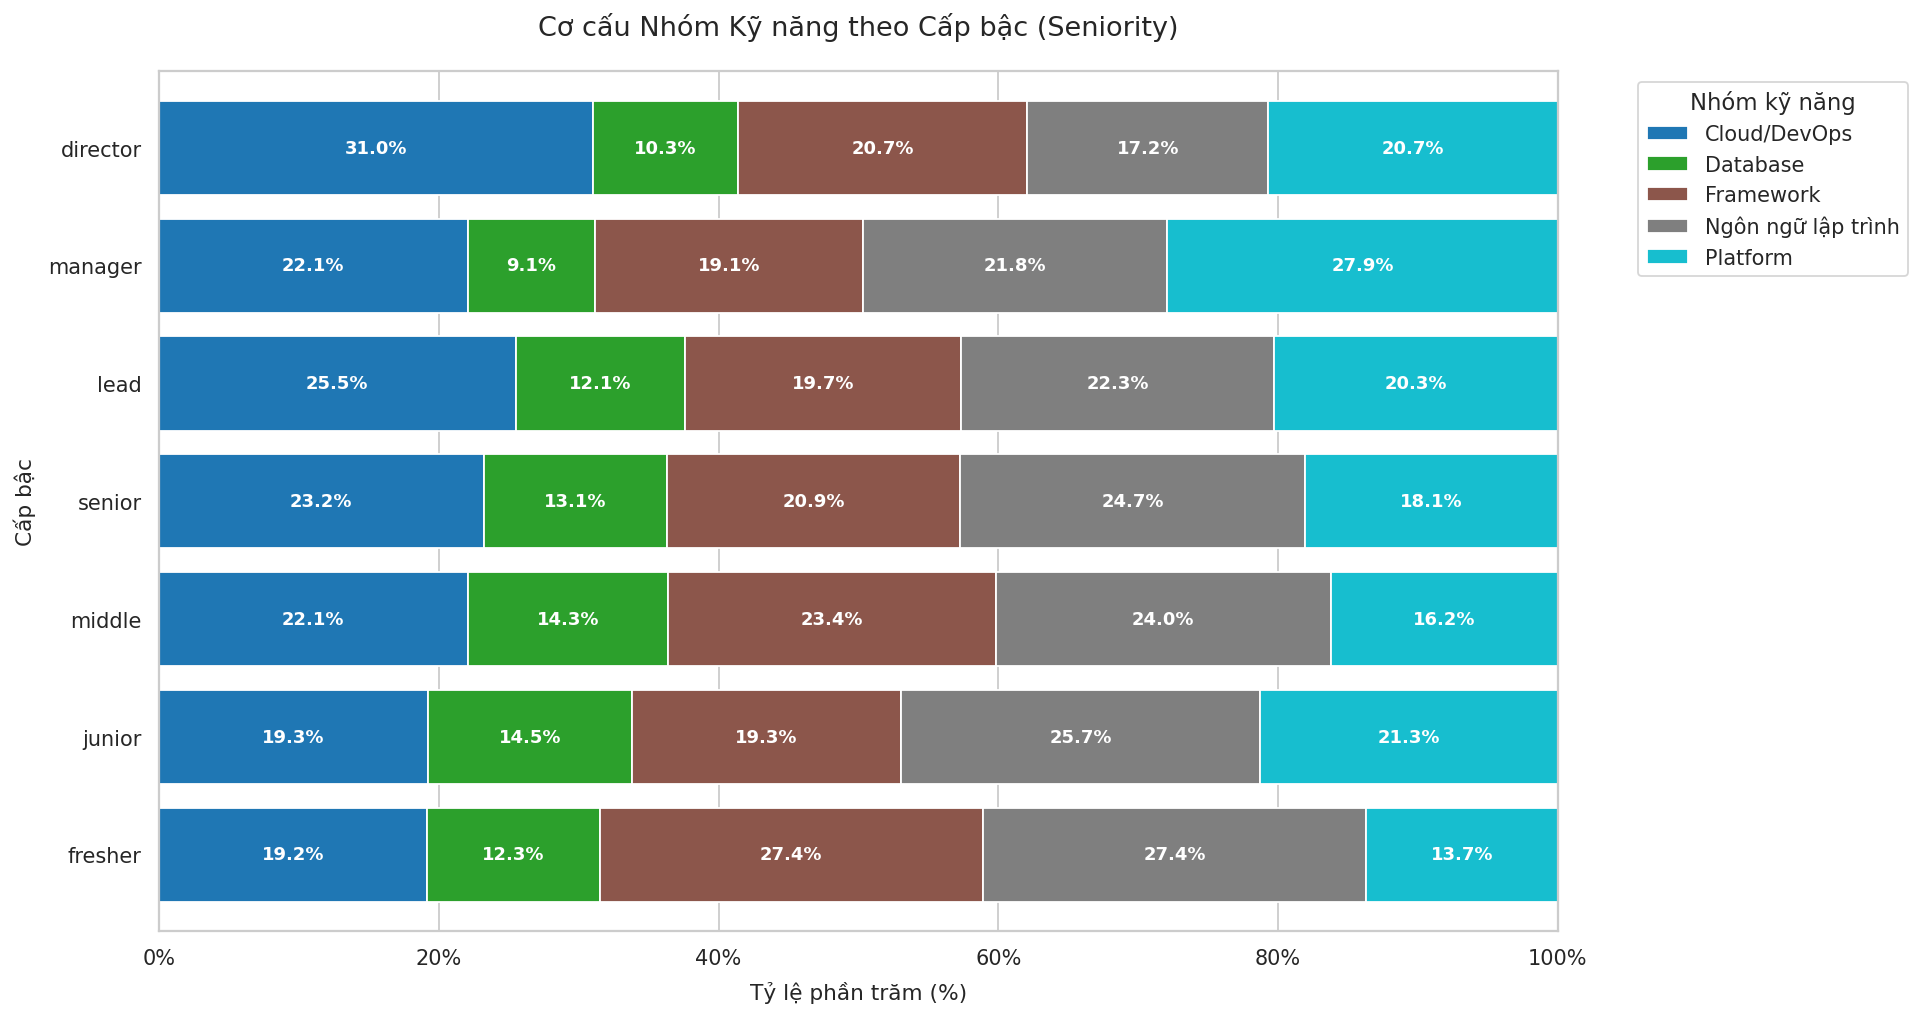

In [10]:
skill_groups_columns = [
    'programming_languages_flat_joined',
    'frameworks_libraries_flat_joined',
    'databases_datastores_flat_joined',
    'cloud_devops_flat_joined',
    'platforms_products_flat_joined'
]

# Tên hiển thị cho các nhóm kỹ năng trên biểu đồ
skill_type_labels = {
    'programming_languages_flat_joined': 'Ngôn ngữ lập trình',
    'frameworks_libraries_flat_joined': 'Framework',
    'databases_datastores_flat_joined': 'Database',
    'cloud_devops_flat_joined': 'Cloud/DevOps',
    'platforms_products_flat_joined': 'Platform'
}

seniority_order = ['fresher', 'junior', 'middle', 'senior', 'lead', 'manager', 'director']

# Lọc bỏ unknown và lấy các cột cần thiết
df_skills = df_city[df_city['seniority_label'].isin(seniority_order)].copy()

skill_data = []

for group_col in skill_groups_columns:
    # Tách các kỹ năng được join bởi dấu phẩy (nếu có) và đếm
    temp_df = df_skills[['seniority_label', group_col]].copy()
    # Loại bỏ các dòng không có kỹ năng ở group này
    temp_df = temp_df.dropna(subset=[group_col])

    # Giả sử mỗi job có thể có nhiều kỹ năng trong 1 group (đã flat_joined)
    # Ta tính tổng số lượng keyword kỹ năng xuất hiện
    temp_df['skill_count'] = temp_df[group_col].str.split(',').str.len()

    # Gom nhóm theo seniority
    summary = temp_df.groupby('seniority_label')['skill_count'].sum().reset_index()
    summary['skill_type'] = skill_type_labels[group_col] # Gán tên hiển thị
    skill_data.append(summary)

df_plot = pd.concat(skill_data)

# Tổng số lượng kỹ năng của mỗi cấp bậc
df_plot['total_skills_in_seniority'] = df_plot.groupby('seniority_label')['skill_count'].transform('sum')
df_plot['percentage'] = (df_plot['skill_count'] / df_plot['total_skills_in_seniority']) * 100
plot_pivot = df_plot.pivot(index='seniority_label', columns='skill_type', values='percentage')
plot_pivot = plot_pivot.reindex(seniority_order) # Sắp xếp theo cấp bậc

ax = plot_pivot.plot(kind='barh', stacked=True, figsize=(15, 8), width=0.8, colormap='tab10')

# Định dạng
plt.title('Cơ cấu Nhóm Kỹ năng theo Cấp bậc (Seniority)', fontsize=15, pad=20)
plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.ylabel('Cấp bậc', fontsize=12)
plt.legend(title='Nhóm kỹ năng', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()
    if width > 5: # Chỉ hiện số nếu diện tích đủ lớn (>5%)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{width:.1f}%', (x, y), ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')

plt.xlim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

Heatmap: Programming Language × Seniority
* Câu hỏi : Ở mỗi seniority level, ngôn ngữ nào được yêu cầu nhiều nhất?
* Cho ai  : Developer đang plan career path — biết mình ở level nào cần học gì.
Phân tích: giải thích mạnh hơn về biểu đồ trên
* Insight  : Python dominant ở Data level, Java ở Senior backend?

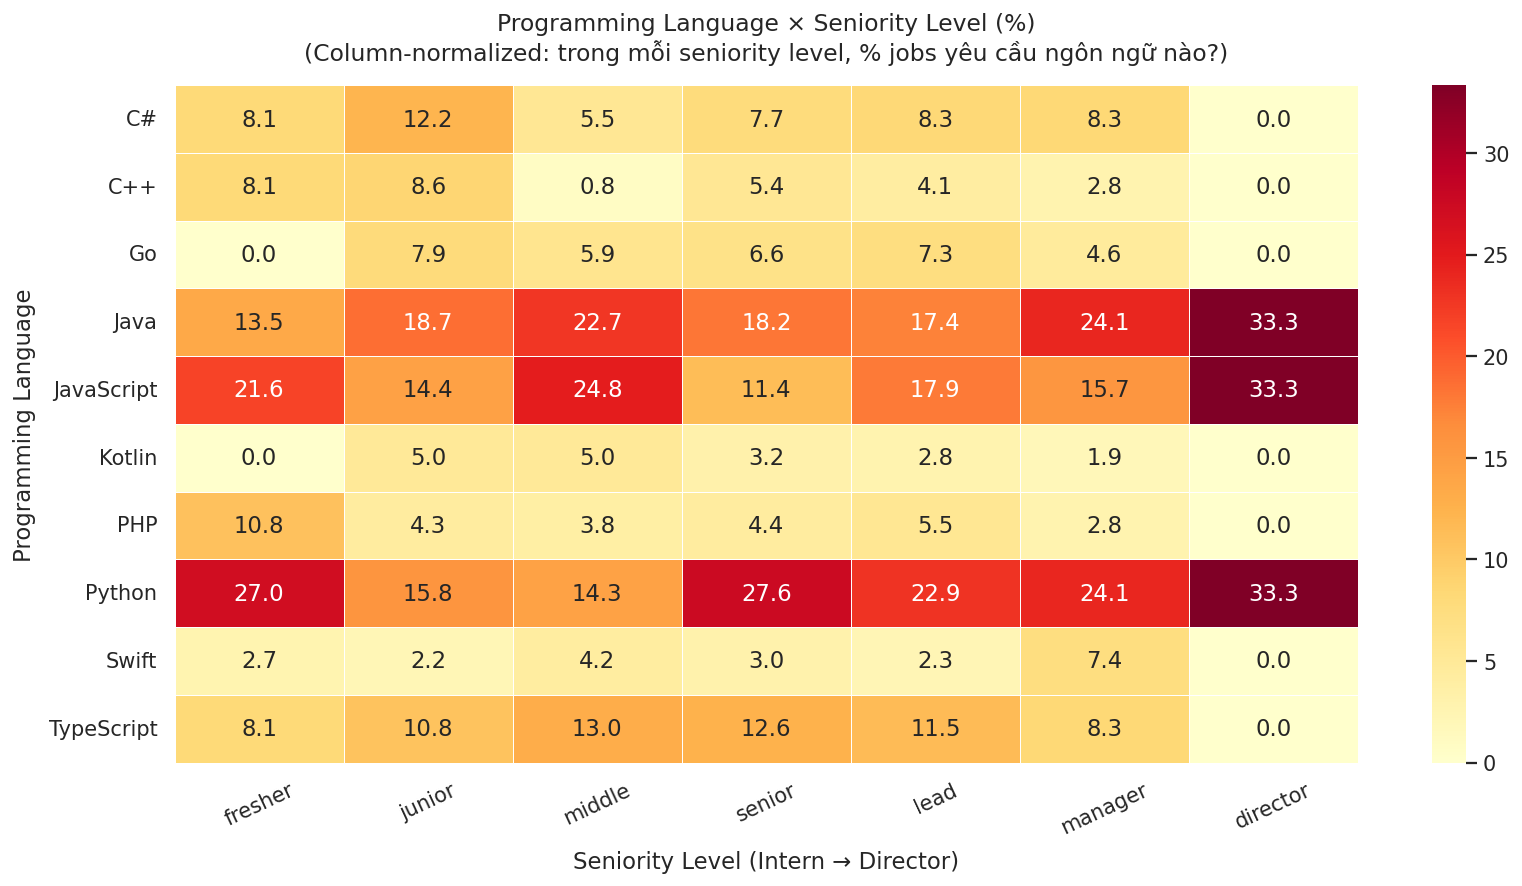

In [ ]:
_tmp_sen = df[['seniority_label', 'programming_languages_flat']].dropna().copy()
_tmp_sen['programming_languages_flat'] = _tmp_sen['programming_languages_flat'].apply(parse_list_col)
_tmp_sen = _tmp_sen.explode('programming_languages_flat')
_tmp_sen['programming_languages_flat'] = _tmp_sen['programming_languages_flat'].str.strip()
_tmp_sen = _tmp_sen[_tmp_sen['programming_languages_flat'].ne('')]


top_langs_sen = _tmp_sen['programming_languages_flat'].value_counts().head(10).index
_tmp_sen = _tmp_sen[_tmp_sen['programming_languages_flat'].isin(top_langs_sen)]

matrix_sen = pd.crosstab(_tmp_sen['programming_languages_flat'], _tmp_sen['seniority_label'])
matrix_sen_pct = matrix_sen.div(matrix_sen.sum(axis=0), axis=1) * 100

# Sắp xếp seniority theo thứ tự có nghĩa
seniority_order = ['fresher', 'junior', 'middle', 'senior', 'lead', 'manager', 'director']
seniority_order = [s for s in seniority_order if s in matrix_sen_pct.columns]
matrix_sen_pct = matrix_sen_pct[seniority_order]

plt.figure(figsize=(13, 7))
sns.heatmap(
    matrix_sen_pct, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.4
)
plt.title('Programming Language × Seniority Level (%)\n'
          '(Column-normalized: trong mỗi seniority level, % jobs yêu cầu ngôn ngữ nào?)')
plt.xlabel('Seniority Level (Intern → Director)')
plt.ylabel('Programming Language')
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


English Requirement Deep Dive by Company Type
* Câu hỏi : Loại công ty nào đòi hỏi English cao? Ở mức nào?
* Cho ai  : Job seeker có/không có English — biết nên target loại công ty nào
* Insight  : Product company = English bắt buộc? Outsourcing = optional?

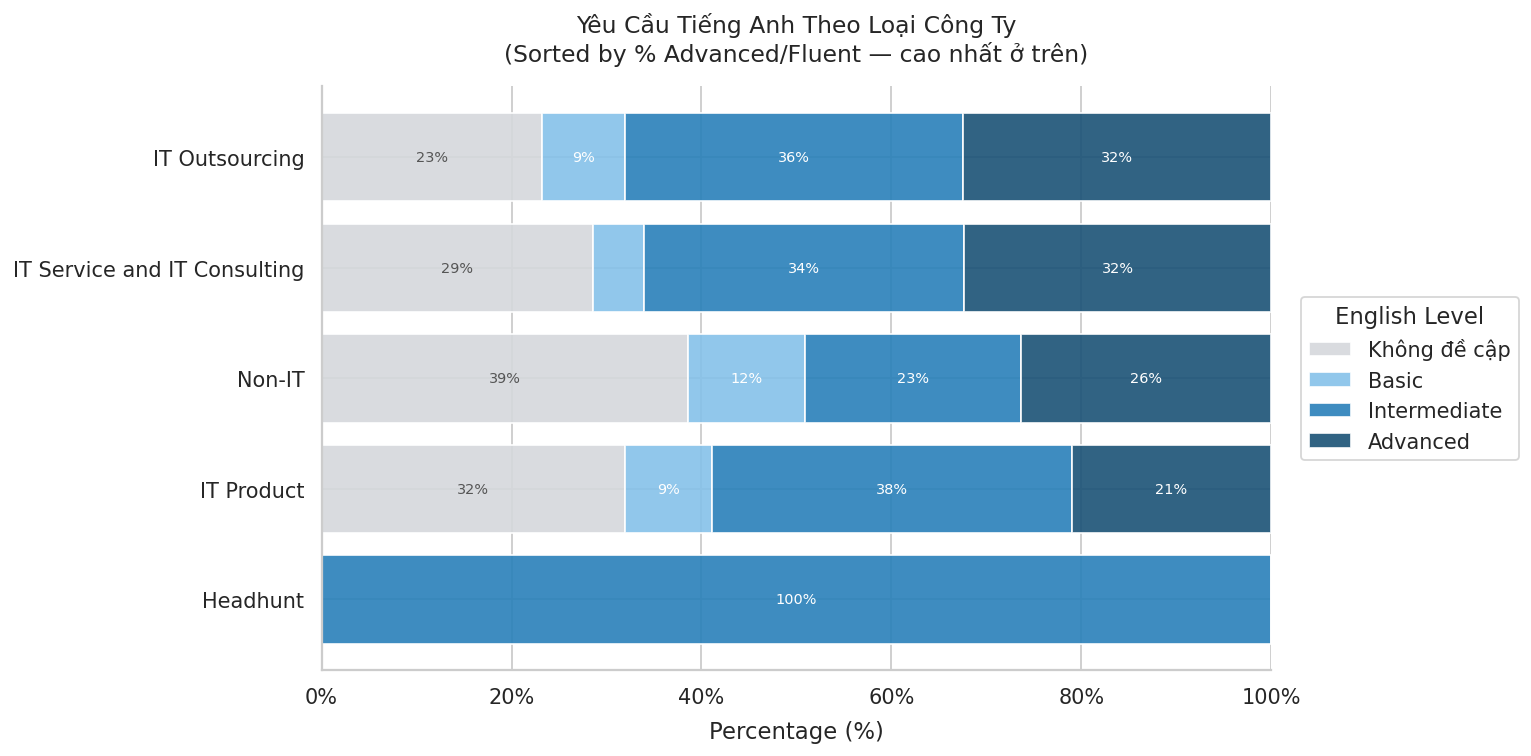

In [ ]:
# English Requirement Deep Dive by Company Type
# Câu hỏi : Loại công ty nào đòi hỏi English cao? Ở mức nào?
# Cho ai  : Job seeker có/không có English — biết nên target loại công ty nào
# Insight  : Product company = English bắt buộc? Outsourcing = optional?

def clean_english(row):
    level = str(row['english_level']).lower().strip()
    langs = row.get('language_requirements_flat', [])

    # parse list nếu cần
    if isinstance(langs, str):
        try:
            langs = ast.literal_eval(langs)
        except:
            langs = []

    langs = [str(x).lower() for x in langs]

    # ===== CASE 1: đã có level rõ =====
    if level in ['basic']:
        return 'Basic'
    elif level in ['intermediate', 'upper-intermediate']:
        return 'Intermediate'
    elif level in ['advanced', 'native-like']:
        return 'Advanced'

    # ===== CASE 2: unknown / none =====
    if 'english' in langs:
        return 'Intermediate'

    return 'Không đề cập'


df['english_tier'] = df.apply(clean_english, axis=1)


tier_order = ['Không đề cập', 'Basic', 'Intermediate', 'Advanced']

eng_by_company = pd.crosstab(
    df['company_type'],
    df['english_tier'],
    normalize='index'
) * 100

eng_by_company = eng_by_company.reindex(columns=tier_order, fill_value=0)


eng_by_company = eng_by_company.sort_values('Advanced', ascending=True)


tier_colors = {
    'Không đề cập':     '#d5d8dc',
    'Basic':            '#85c1e9',
    'Intermediate':     '#2980b9',
    'Advanced':'#1a5276',
}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(eng_by_company))

for tier in tier_order:
    vals = eng_by_company[tier].values

    bars = ax.barh(
        eng_by_company.index,
        vals,
        left=bottom,
        color=tier_colors[tier],
        label=tier,
        alpha=0.9
    )

    # annotate %
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 7:
            ax.text(
                bottom[i] + v / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.0f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='white' if tier != 'Không đề cập' else '#555'
            )

    bottom += vals


ax.set_xlabel('Percentage (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title(
    'Yêu Cầu Tiếng Anh Theo Loại Công Ty\n'
    '(Sorted by % Advanced/Fluent — cao nhất ở trên)'
)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title='English Level'
)
ax.set_xlim(0, 100)

sns.despine()
plt.tight_layout()
plt.show()

# **III. SỰ KHÁC BIỆT HAI THÀNH PHỐ**

Expertise Difference: TPHCM vs Hà Nội (Diverging Bar)
* Câu hỏi : Hai thành phố khác nhau ở loại nhân sự nào?
* Cho ai  : Job seeker đang cân nhắc địa điểm làm việc
* Insight  : TPHCM thiên về loại nào, Hà Nội thiên về loại nào

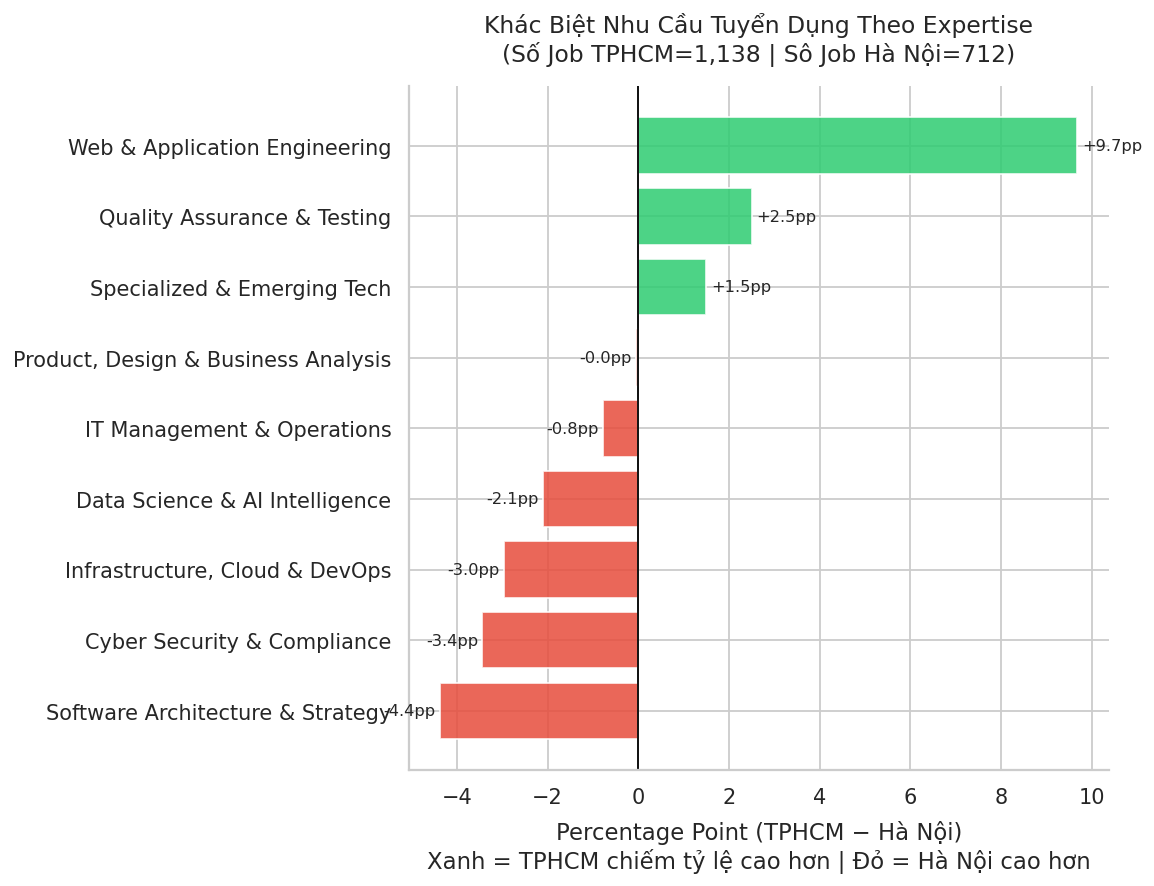

In [ ]:
table_city_exp = pd.crosstab(
    df_city['city_group'],
    df_expertise_group.set_index(df.index)['expertise_group'].reindex(df_city.index),
    normalize='index'
) * 100

_tmp_city_exp = df_city.merge(
    df_expertise_group[['elem_id', 'expertise_group']].drop_duplicates('elem_id'),
    on='elem_id', how='left'
) if 'elem_id' in df_city.columns else df_city.merge(
    df_expertise_group[['expertise_group']],
    left_index=True, right_index=True, how='left'
)

table_city_exp = pd.crosstab(
    _tmp_city_exp['city_group'],
    _tmp_city_exp['expertise_group'],
    normalize='index'
) * 100

diff = table_city_exp.loc['TPHCM'] - table_city_exp.loc['Hà Nội']
diff = diff.sort_values()

# Thêm n count để reader biết statistical weight
n_tphcm = (df_city['city_group'] == 'TPHCM').sum()
n_hn = (df_city['city_group'] == 'Hà Nội').sum()

fig, ax = plt.subplots(figsize=(9, 7))
colors_div = ['#e74c3c' if x < 0 else '#2ecc71' for x in diff]

ax.barh(diff.index, diff.values, color=colors_div, alpha=0.85)
ax.axvline(0, color='black', lw=1)

for i, v in enumerate(diff.values):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.1 if v >= 0 else -0.1
    ax.text(v + offset, i, f'{v:+.1f}pp', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Percentage Point (TPHCM − Hà Nội)\nXanh = TPHCM chiếm tỷ lệ cao hơn | Đỏ = Hà Nội cao hơn')
ax.set_title(f'Khác Biệt Nhu Cầu Tuyển Dụng Theo Expertise\n'
             f'(Số Job TPHCM={n_tphcm:,} | Sô Job Hà Nội={n_hn:,})')
sns.despine()
plt.tight_layout()
plt.show()

Company Size: TPHCM vs Hà Nội
* Câu hỏi : Phân bố quy mô công ty ở hai thành phố?
* Cho ai  : Job seeker cân nhắc tìm việc. Phân tích: sự khác nhau của thị trường 2 thành phố
* Insight  : TPHCM thiên về loại nào, Hà Nội thiên về loại nào

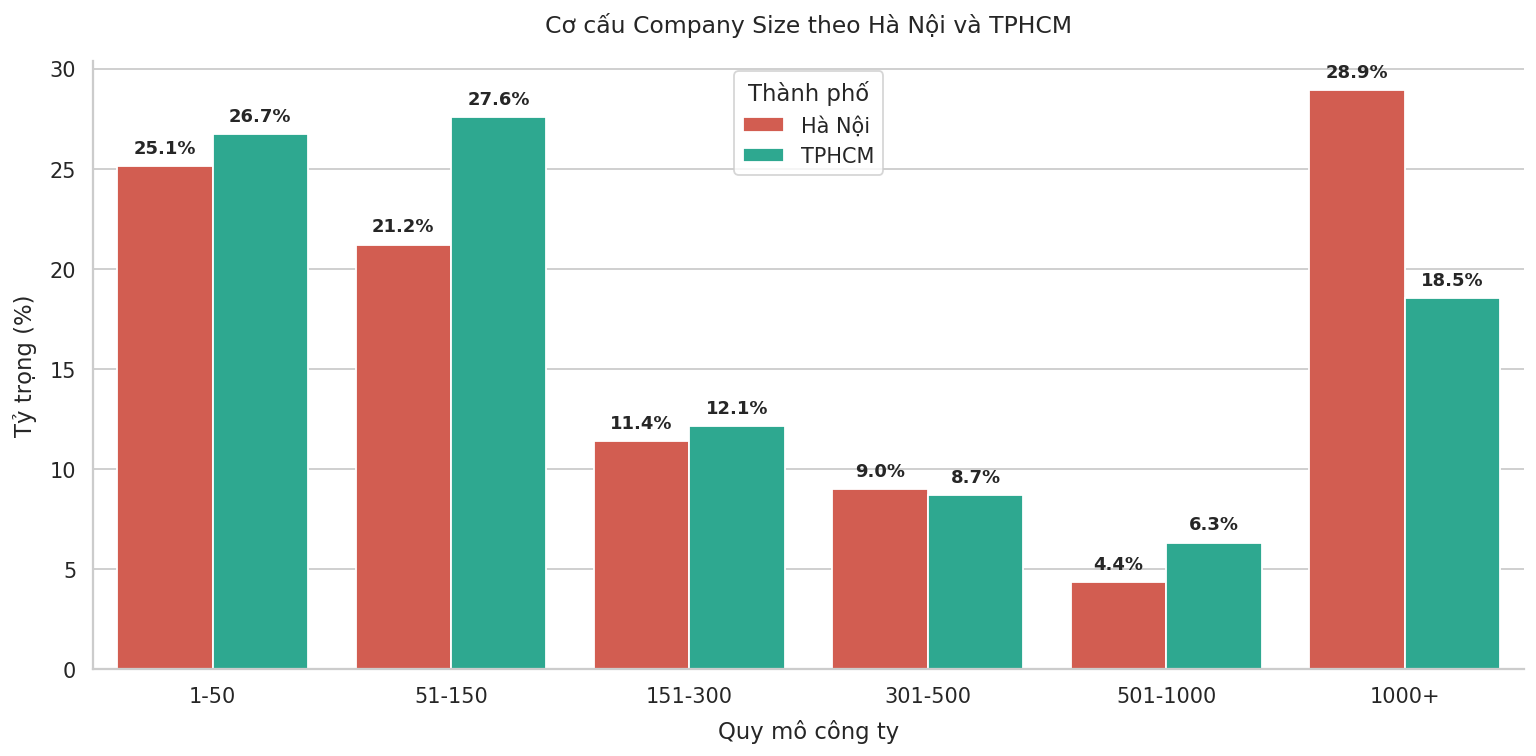

In [ ]:
df_city_size = df_city[df_city["company_size"].notna()].copy()

size_order = [
    "1-50",
    "51-150",
    "151-300",
    "301-500",
    "501-1000",
    "1000+"
]

existing_order = [s for s in size_order if s in df_city_size["company_size"].unique()]
if not existing_order:
    existing_order = sorted(df_city_size["company_size"].dropna().unique())

# Count
grouped = (
    df_city_size.groupby(["city_group", "company_size"])
    .size()
    .reset_index(name="Job Count")
)

# Normalize theo từng city
grouped["Percent"] = grouped.groupby("city_group")["Job Count"].transform(
    lambda x: x / x.sum() * 100
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=grouped,
    x="company_size",
    y="Percent",
    hue="city_group",
    order=existing_order,
    palette=CITY_COLORS
)

# annotate %
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold"
        )

plt.title("Cơ cấu Company Size theo Hà Nội và TPHCM", pad=16)
plt.xlabel("Quy mô công ty")
plt.ylabel("Tỷ trọng (%)")
plt.legend(title="Thành phố")
sns.despine()
plt.tight_layout()
plt.show()

Working Model — TPHCM vs Hà Nội (grouped bar)
* Câu hỏi : Thị trường đang chấp nhận remote/hybrid ở mức nào? Hai thành phố khác nhau không?
* Cho ai  : Job seeker — kỳ vọng về hình thức làm việc
* Insight  : Hybrid có đang trở thành mainstream chưa hay At office vẫn áp đảo?

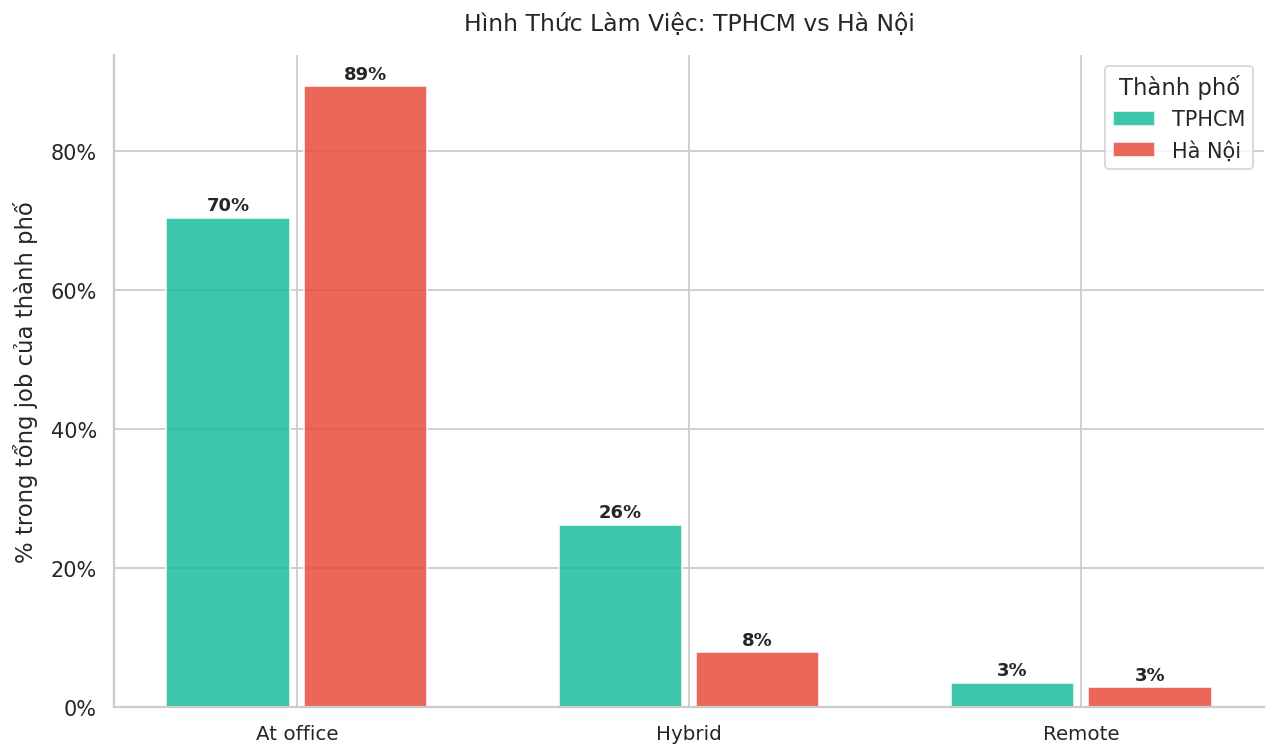

In [ ]:
wm_order = ['At office', 'Hybrid', 'Remote']

wm_by_city = (
    df_city.groupby(['city_group', 'working_model'])
    .size()
    .reset_index(name='count')
)
wm_by_city['pct'] = wm_by_city.groupby('city_group')['count'].transform(lambda x: x / x.sum() * 100)

cities = ['TPHCM', 'Hà Nội']
x = np.arange(len(wm_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i, city in enumerate(cities):
    subset = wm_by_city[wm_by_city['city_group'] == city].set_index('working_model')
    vals = [subset.loc[wm, 'pct'] if wm in subset.index else 0 for wm in wm_order]
    bars = ax.bar(x + i * width, vals, width * 0.9,
                  label=city, color=CITY_COLORS[city], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(wm_order, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% trong tổng job của thành phố')
ax.set_title('Hình Thức Làm Việc: TPHCM vs Hà Nội')
ax.legend(title='Thành phố')
sns.despine()
plt.tight_layout()
plt.show()

Seniority Distribution — TPHCM vs Hà Nội
* Câu hỏi : Hai thành phố đang tuyển ở cấp bậc nào là chủ yếu? Có khác nhau không?
* Cho ai  : Job seeker — biết thị trường đang cần level nào ở từng thành phố
* Insight  : TPHCM thiên senior hơn? Hà Nội nhiều fresher/junior hơn?

/tmp/ipykernel_830/759248254.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



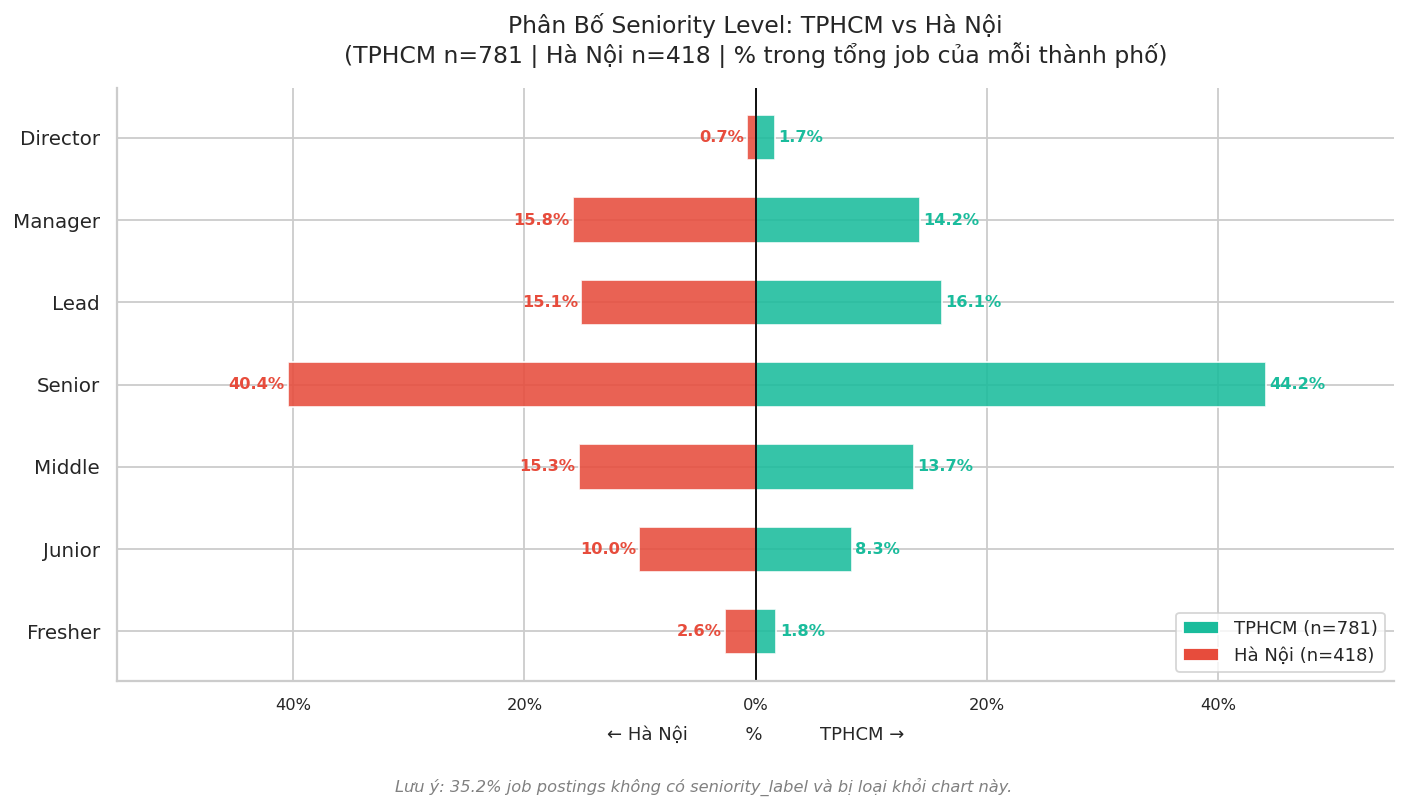

In [25]:
SENIORITY_ORDER = ['fresher', 'junior', 'middle', 'senior', 'lead', 'manager', 'director']

_tmp_sen_city = df_city.copy()

valid_levels = [s for s in SENIORITY_ORDER if s in _tmp_sen_city['seniority_label'].dropna().unique()]

_tmp_sen_city = _tmp_sen_city[_tmp_sen_city['seniority_label'].isin(valid_levels)]

n_tphcm = (_tmp_sen_city['city_group'] == 'TPHCM').sum()
n_hn    = (_tmp_sen_city['city_group'] == 'Hà Nội').sum()

sen_by_city = (
    _tmp_sen_city
    .groupby(['city_group', 'seniority_label'])
    .size()
    .reset_index(name='count')
)
sen_by_city['pct'] = (
    sen_by_city
    .groupby('city_group')['count']
    .transform(lambda x: x / x.sum() * 100)
)

pivot = sen_by_city.pivot(index='seniority_label', columns='city_group', values='pct').reindex(valid_levels).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))

bar_h = 0.55

for i, level in enumerate(valid_levels):
    val_tphcm =  pivot.loc[level, 'TPHCM'] if 'TPHCM'   in pivot.columns else 0
    val_hn    = -pivot.loc[level, 'Hà Nội'] if 'Hà Nội' in pivot.columns else 0

    ax.barh(i,  val_tphcm, height=bar_h, color=CITY_COLORS['TPHCM'], alpha=0.88)
    ax.barh(i,  val_hn,    height=bar_h, color=CITY_COLORS['Hà Nội'], alpha=0.88)

    if abs(val_tphcm) > 0.5:
        ax.text(val_tphcm + 0.3,  i, f'{val_tphcm:.1f}%',  va='center', ha='left',  fontsize=9, color=CITY_COLORS['TPHCM'],  fontweight='bold')
    if abs(val_hn) > 0.5:
        ax.text(val_hn    - 0.3,  i, f'{abs(val_hn):.1f}%', va='center', ha='right', fontsize=9, color=CITY_COLORS['Hà Nội'], fontweight='bold')

ax.set_yticks(range(len(valid_levels)))
ax.set_yticklabels([l.capitalize() for l in valid_levels], fontsize=11)
ax.axvline(0, color='black', lw=1)

max_val = max(pivot.max().max(), 1)
ax.set_xlim(-max_val * 1.25, max_val * 1.25)

xticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(v):.0f}%' for v in xticks], fontsize=9)

ax.set_xlabel('← Hà Nội          %          TPHCM →', fontsize=10)
ax.set_title(
    f'Phân Bố Seniority Level: TPHCM vs Hà Nội\n'
    f'(TPHCM n={n_tphcm:,} | Hà Nội n={n_hn:,} | % trong tổng job của mỗi thành phố)',
    pad=14
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=CITY_COLORS['TPHCM'], label=f'TPHCM (n={n_tphcm:,})'),
    Patch(facecolor=CITY_COLORS['Hà Nội'], label=f'Hà Nội (n={n_hn:,})'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

missing_rate = (df_city['seniority_label'] == 'unknown').mean() * 100
plt.figtext(
    0.5, -0.03,
    f'Lưu ý: {missing_rate:.1f}% job postings không có seniority_label và bị loại khỏi chart này.',
    ha='center', fontsize=9, style='italic', color='gray'
)

sns.despine()
plt.tight_layout()
plt.show()

Original Distribution — TPHCM vs Hà Nội
* Câu hỏi : Nguồn gốc của hai công ty là local hay đa quốc gia?
* Cho ai  : Data Analyst - biết tại sao biểu đồ trên lại nghiêng về TPHCM?
* Insight  : giải thích rõ biểu đồ trên

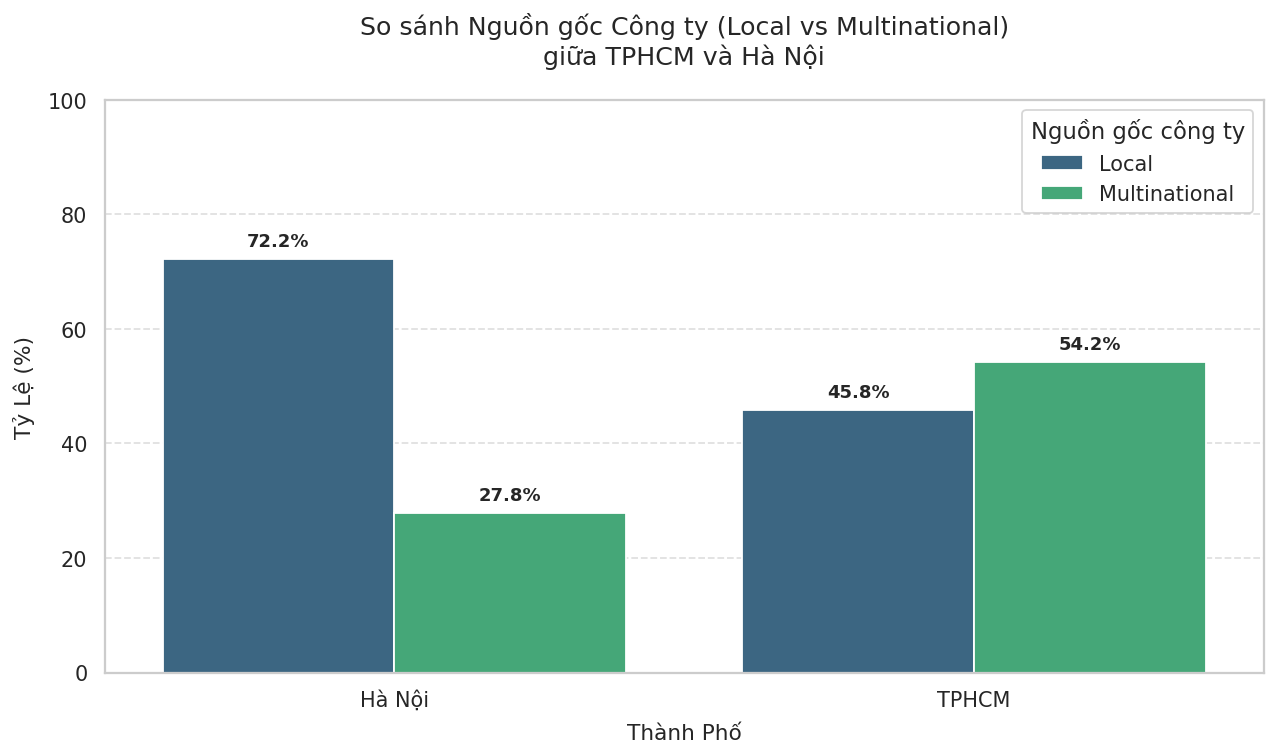

In [5]:
df_origin = df_city[df_city['city_group'].isin(['TPHCM', 'Hà Nội'])].copy()

# Tạo biến company_origin: Nếu là Vietnam -> Local, ngược lại -> Multinational
df_origin['company_origin'] = df_origin['country'].apply(
    lambda x: 'Local' if x == 'Vietnam' else 'Multinational'
)

origin_counts = (
    df_origin.groupby(['city_group', 'company_origin'])
    .size()
    .reset_index(name='count')
)

origin_counts['percentage'] = origin_counts.groupby('city_group')['count'].transform(
    lambda x: x / x.sum() * 100
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=origin_counts,
    x='city_group',
    y='percentage',
    hue='company_origin',
    palette='viridis'

plt.title('So sánh Nguồn gốc Công ty (Local vs Multinational)\ngiữa TPHCM và Hà Nội',
          fontsize=14, pad=20)
plt.xlabel('Thành Phố', fontsize=12)
plt.ylabel('Tỷ Lệ (%)', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.legend(title='Nguồn gốc công ty')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **IV. SỰ XUẤT HIỆN CỦA AI**

Phân bố theo loại hình công ty cho bài đăng AI

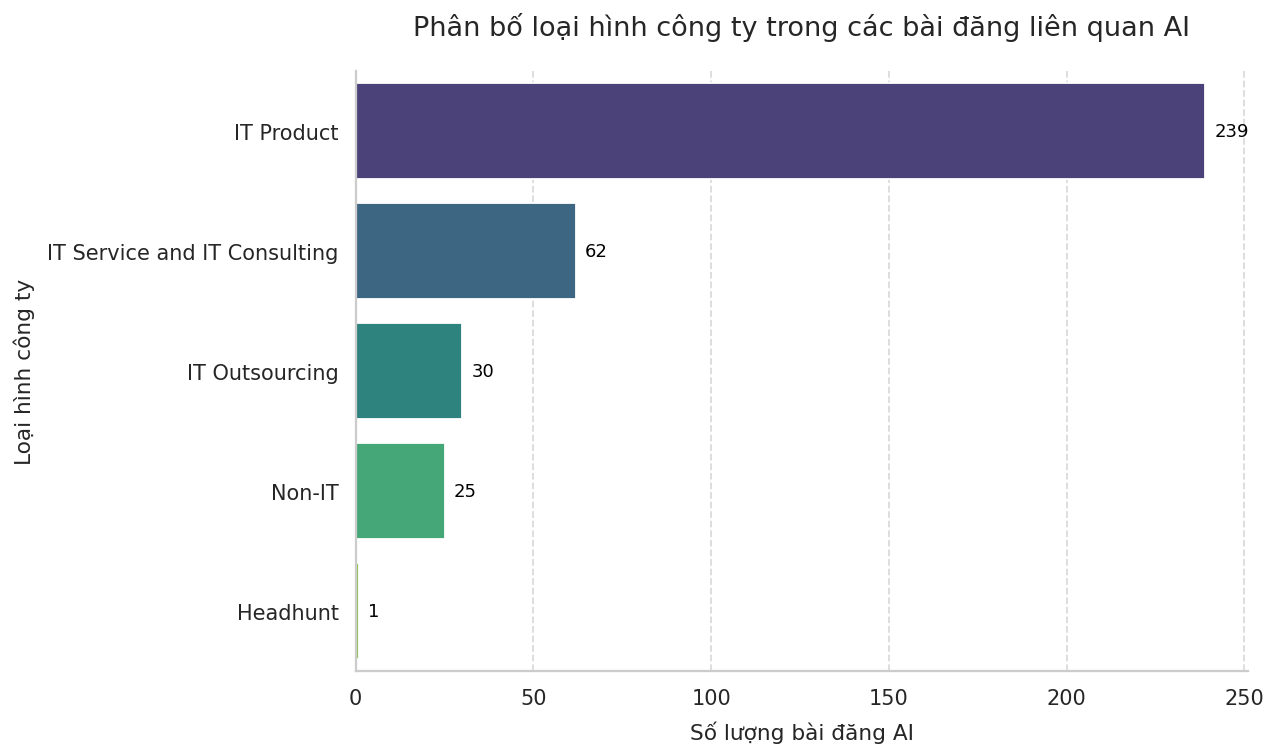

In [6]:
# 1. Tính toán phân bố các loại hình công ty trong df_ai
company_type_ai_counts = df_ai['company_type'].value_counts().reset_index()
company_type_ai_counts.columns = ['company_type', 'count']

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=company_type_ai_counts,
    x='count',
    y='company_type',
    hue='company_type',
    palette='viridis',
    legend=False
)

plt.title('Phân bố loại hình công ty trong các bài đăng liên quan AI', fontsize=15, pad=20)
plt.xlabel('Số lượng bài đăng AI', fontsize=12)
plt.ylabel('Loại hình công ty', fontsize=12)

# Annotate số lượng trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10,
                color='black')

plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid trên trục x cho biểu đồ ngang
sns.despine()
plt.tight_layout()
plt.show()

Phân bố AI theo lĩnh vực công nghệ có tuyển dụng AI nhiều nhất

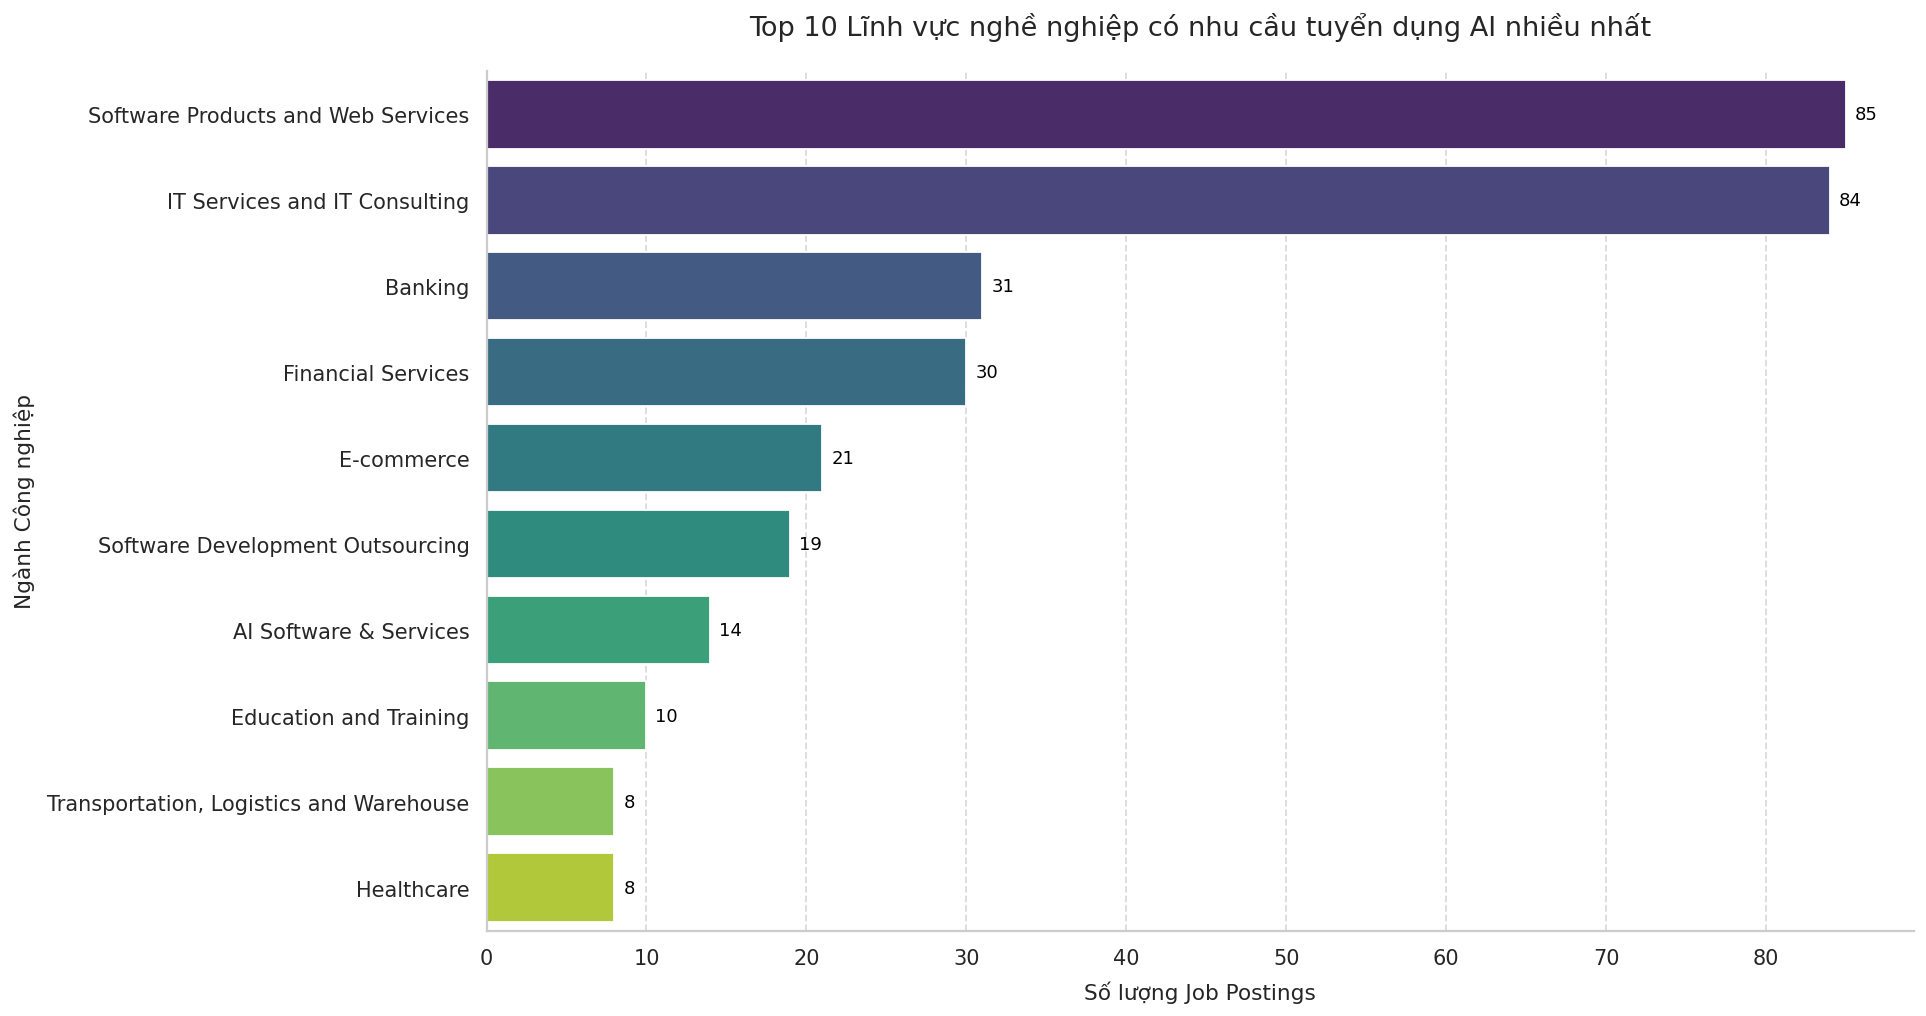

In [15]:
top_ai_industries = df_ai['company_industry'].value_counts().head(10).reset_index()
top_ai_industries.columns = ['company_industry', 'count']

plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=top_ai_industries,
    x='count',
    y='company_industry',
    hue='company_industry', # Assign y variable to hue
    palette='viridis',
    legend=False # Set legend=False
)

plt.title('Top 10 Lĩnh vực nghề nghiệp có nhu cầu tuyển dụng AI nhiều nhất', fontsize=15, pad=20)
plt.xlabel('Số lượng Job Postings', fontsize=12)
plt.ylabel('Ngành Công nghiệp', fontsize=12)

# Annotate số lượng trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10,
                color='black')

plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

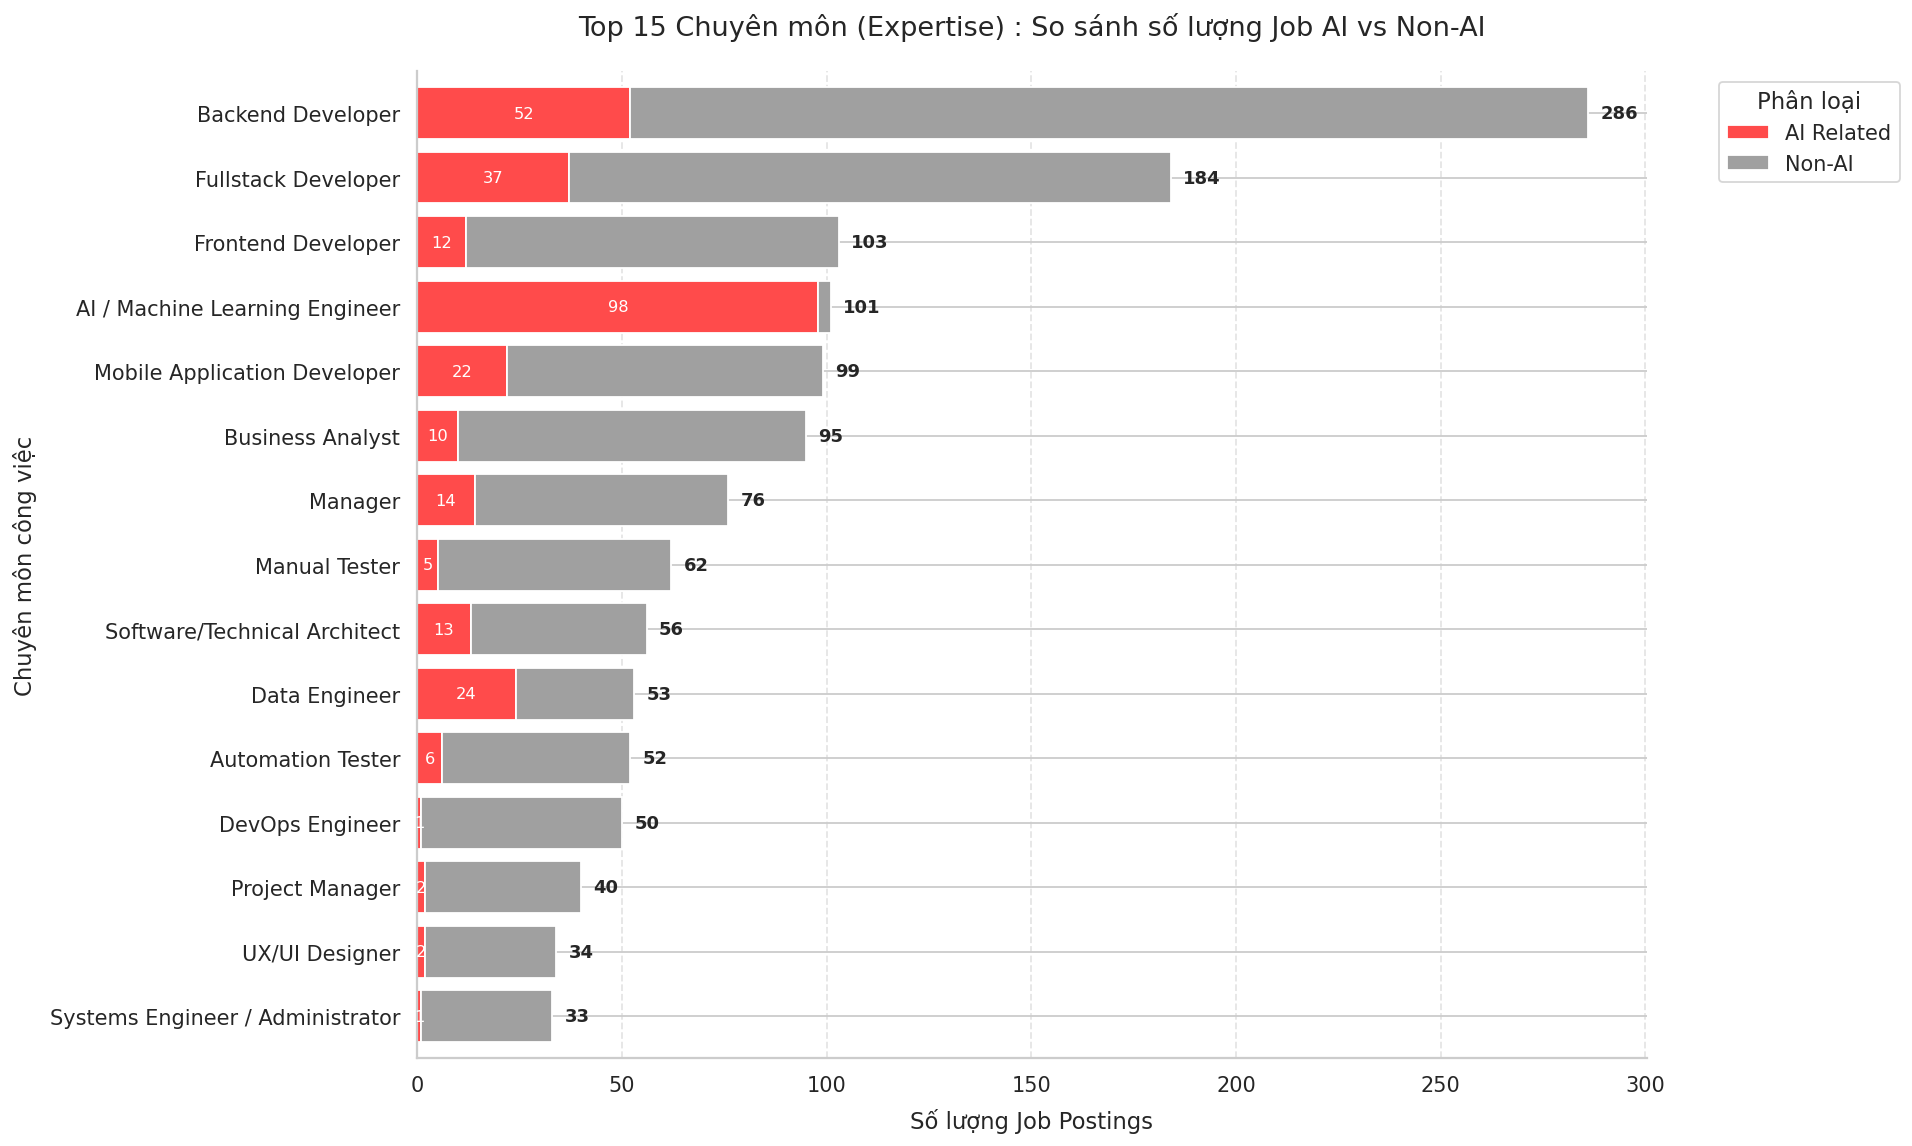

In [17]:

top_15_names = df_city['job_expertise'].value_counts().head(15).index

#Lấy top 15
df_top15 = df_city[df_city['job_expertise'].isin(top_15_names)].copy()
df_top15['is_ai'] = df_top15['elem_id'].isin(df_ai['elem_id']).map({True: 'AI Related', False: 'Non-AI'})

# 3. Gom nhóm để tính số lượng
stacked_data = (
    df_top15.groupby(['job_expertise', 'is_ai'])
    .size()
    .reset_index(name='count')
)

# 4. Pivot dữ liệu để vẽ cột chồng
plot_data = stacked_data.pivot(index='job_expertise', columns='is_ai', values='count').fillna(0)

# Sắp xếp lại theo tổng số lượng để biểu đồ trông đẹp hơn (giảm dần)
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('total', ascending=True).drop(columns='total')

# 5. Vẽ biểu đồ
# Sử dụng mã màu: AI (thường chọn màu nổi bật như Đỏ/Cam), Non-AI (màu trung tính như Xám/Xanh nhạt)
colors = {'AI Related': '#FF4B4B', 'Non-AI': '#A0A0A0'}

ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(15, 9),
    width=0.8,
    color=[colors[col] for col in plot_data.columns]
)

# 6. Định dạng và Annotate
plt.title("Top 15 Chuyên môn (Expertise) : So sánh số lượng Job AI vs Non-AI", fontsize=15, pad=20)
plt.xlabel("Số lượng Job Postings")
plt.ylabel("Chuyên môn công việc")

# Annotate tổng số lượng ở cuối mỗi thanh
for i, (name, row) in enumerate(plot_data.iterrows()):
    total = row.sum()
    ai_val = row.get('AI Related', 0)

    # Ghi tổng số ở đầu thanh
    plt.text(total + 3, i, f'{int(total)}', va='center', fontsize=10, fontweight='bold')

    # Nếu phần AI đủ lớn, ghi chú thêm số lượng AI ngay trên thanh
    if ai_val > 0:
        # Tìm vị trí x của phần AI (thường nằm ở đầu hoặc cuối tùy thứ tự cột)
        # Nếu AI Related là cột đầu tiên:
        plt.text(ai_val/2, i, f'{int(ai_val)}', va='center', ha='center', color='white', fontsize=9)

plt.legend(title="Phân loại", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

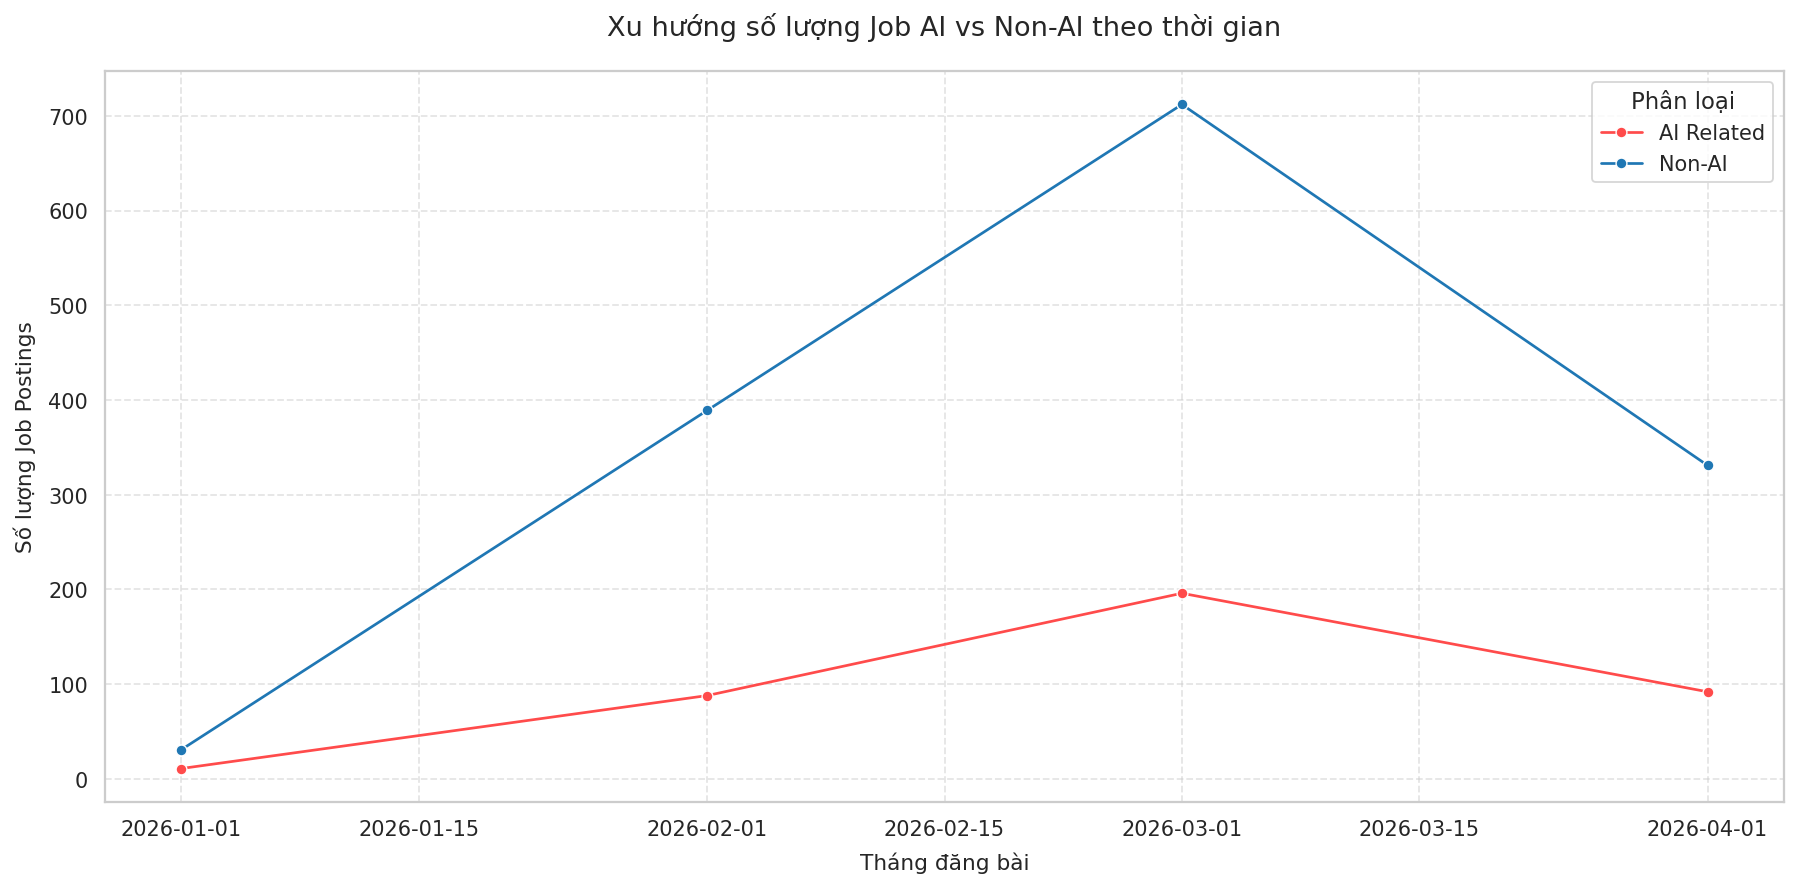

In [18]:
# 1. Chuẩn bị dữ liệu thời gian
df_time = df_city.copy()
df_time['date_posted_clean'] = pd.to_datetime(df_time['date_posted_clean'])

df_time['is_ai'] = df_time['elem_id'].isin(df_ai['elem_id']).map({True: 'AI Related', False: 'Non-AI'})

# 'MS' là viết tắt của Month Start
time_series = (
    df_time.groupby([pd.Grouper(key='date_posted_clean', freq='MS'), 'is_ai'])
    .size()
    .reset_index(name='job_count')
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=time_series,
    x='date_posted_clean',
    y='job_count',
    hue='is_ai',
    marker='o',
    palette={'AI Related': '#FF4B4B', 'Non-AI': '#1f77b4'}
)
time_pivot = time_series.pivot(index='date_posted_clean', columns='is_ai', values='job_count').fillna(0)
time_pivot['ai_share'] = (time_pivot['AI Related'] / (time_pivot['AI Related'] + time_pivot['Non-AI']) * 100)
plt.title('Xu hướng số lượng Job AI vs Non-AI theo thời gian', fontsize=15, pad=20)
plt.xlabel('Tháng đăng bài', fontsize=12)
plt.ylabel('Số lượng Job Postings', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Phân loại')
plt.tight_layout()
plt.show()